In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='white')
sns.set_palette("deep")

In [2]:
df = pd.read_csv('D:/ProjectPython/GitHub Represitories/machine-learning-homework/archive/wine-clustering.csv')
df

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


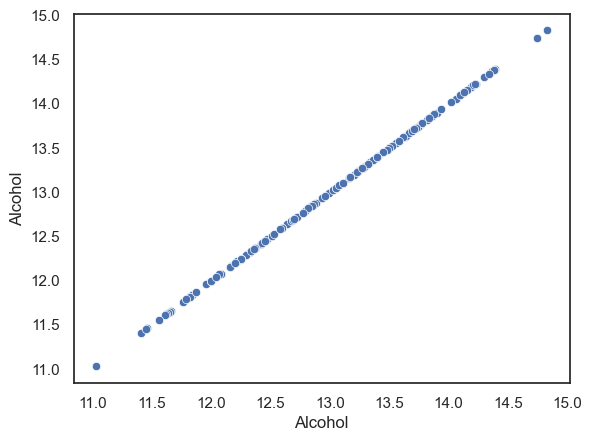

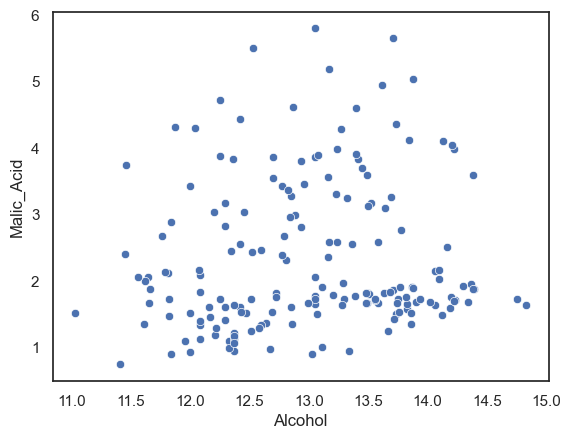

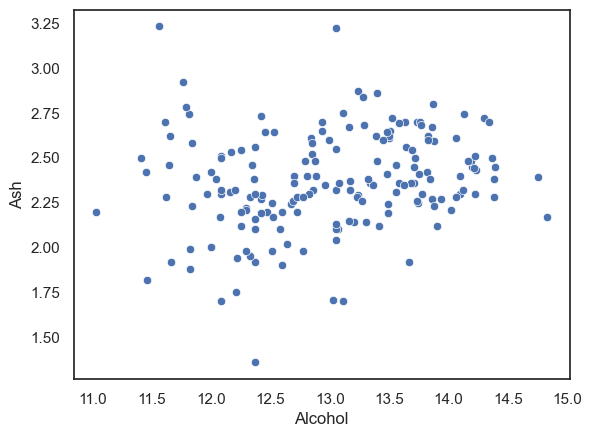

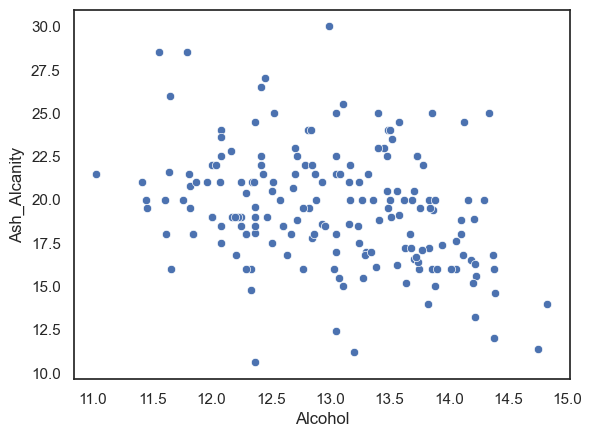

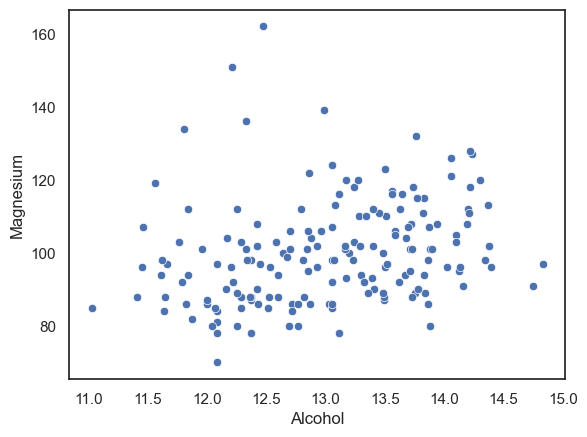

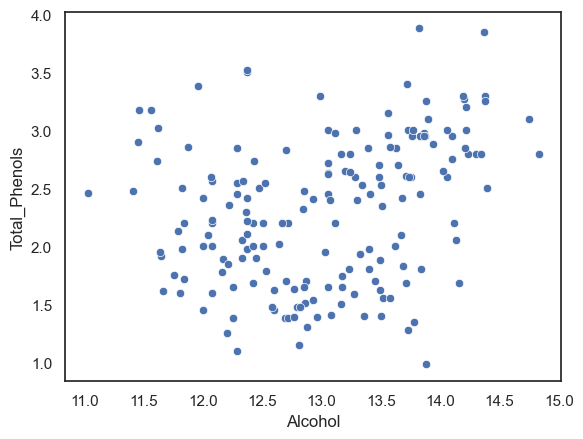

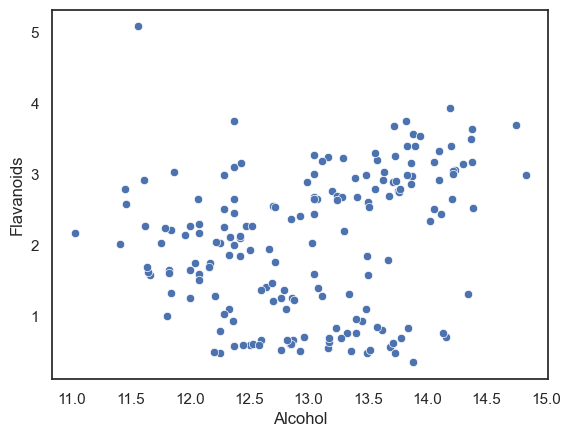

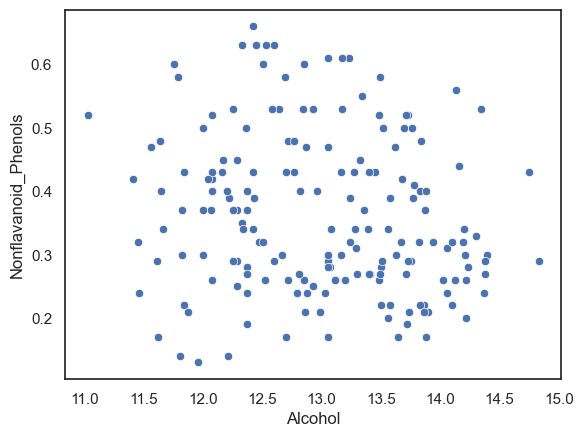

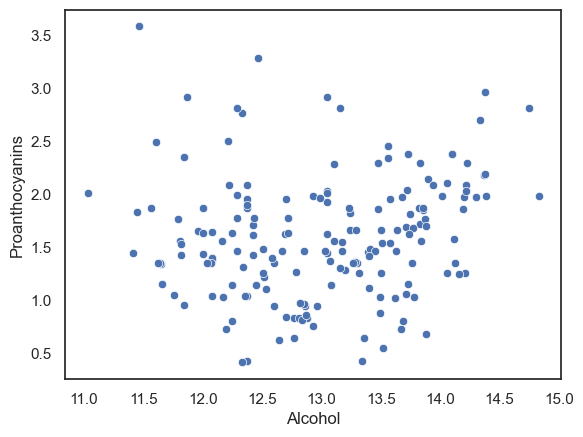

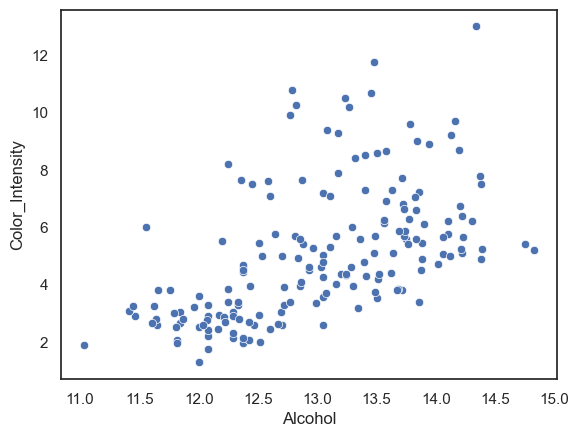

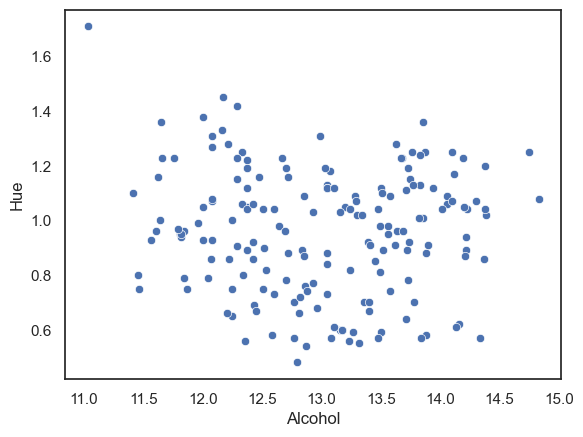

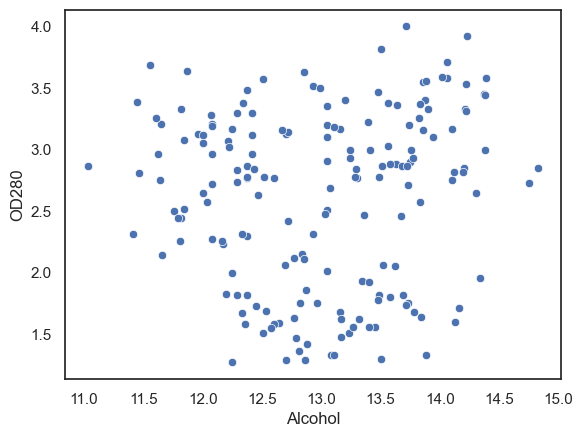

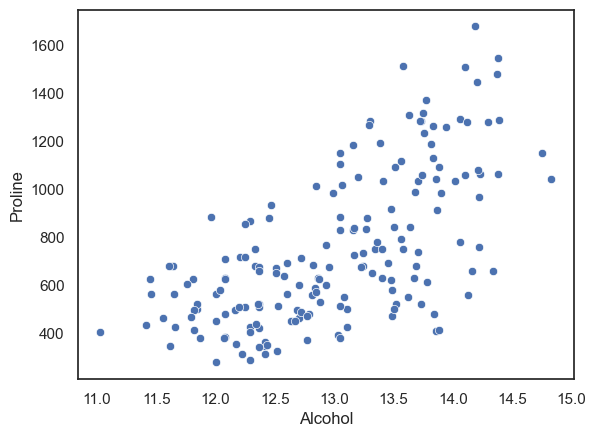

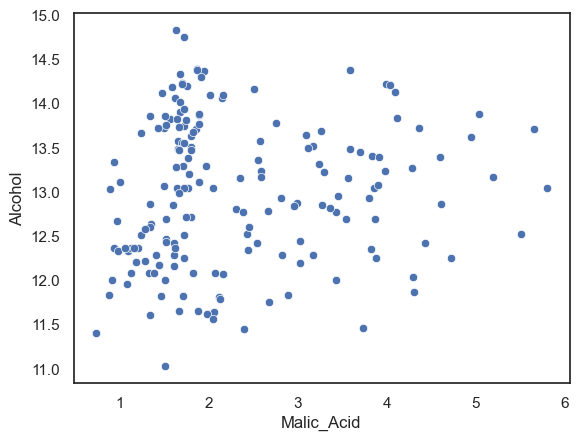

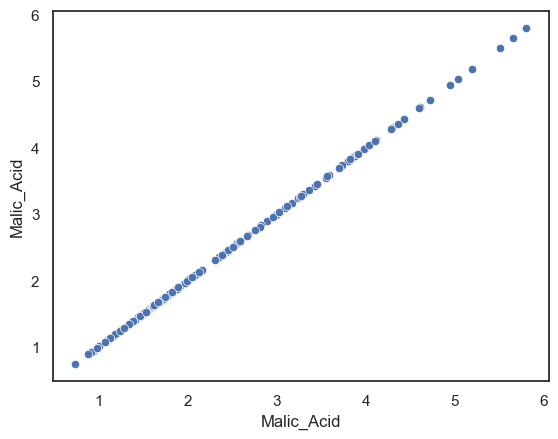

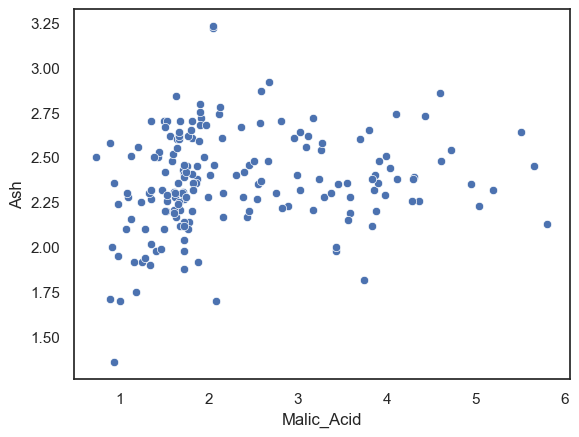

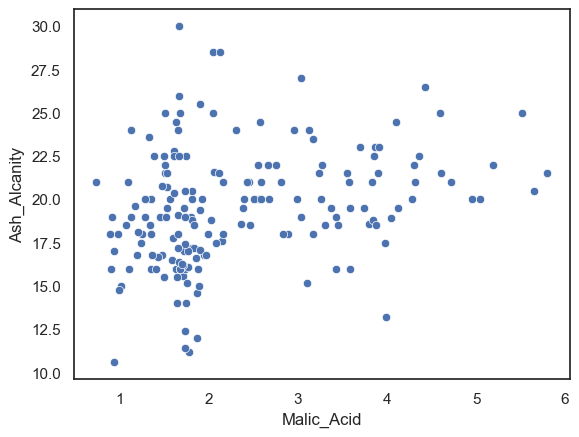

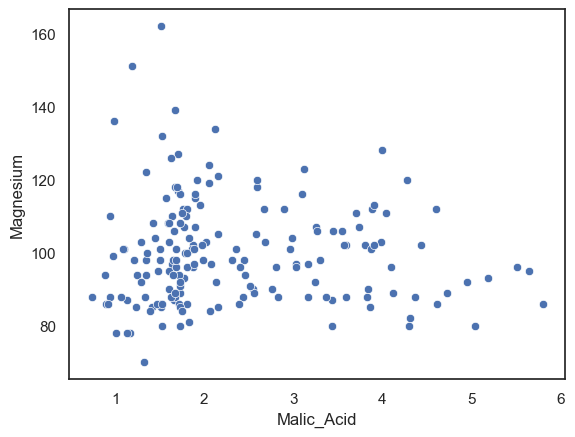

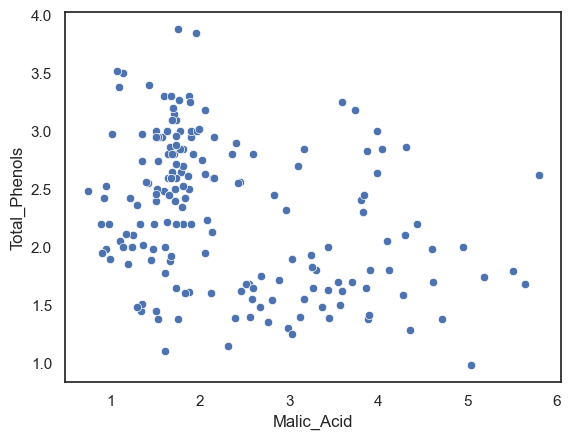

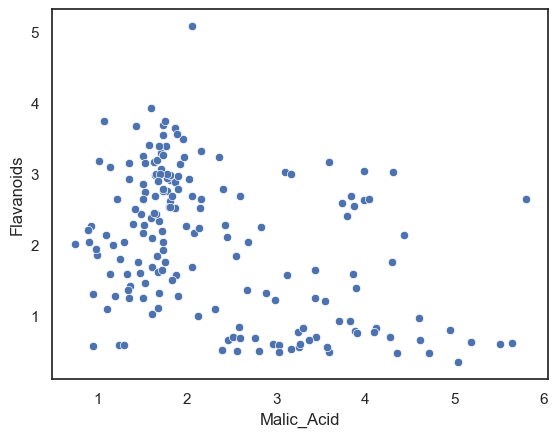

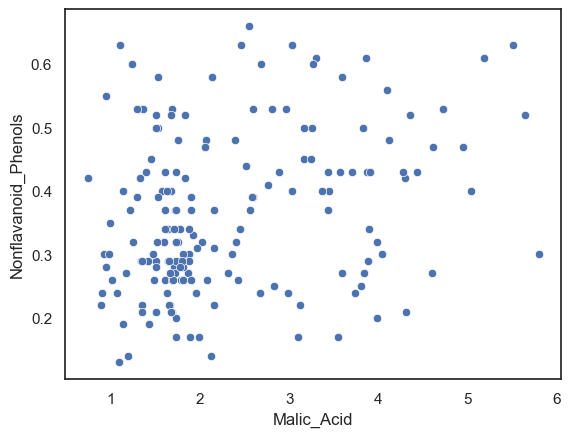

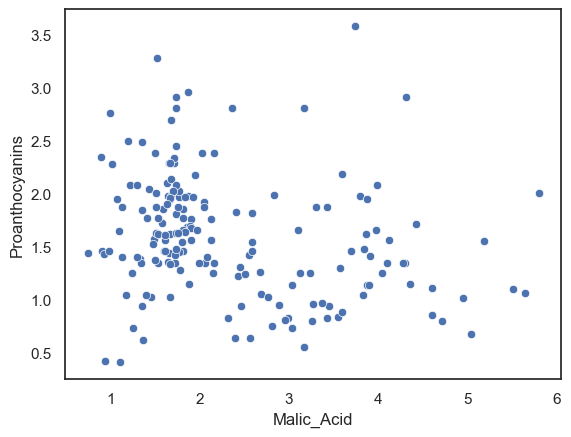

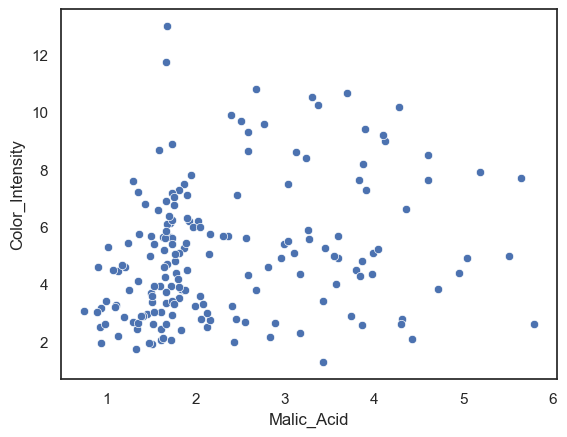

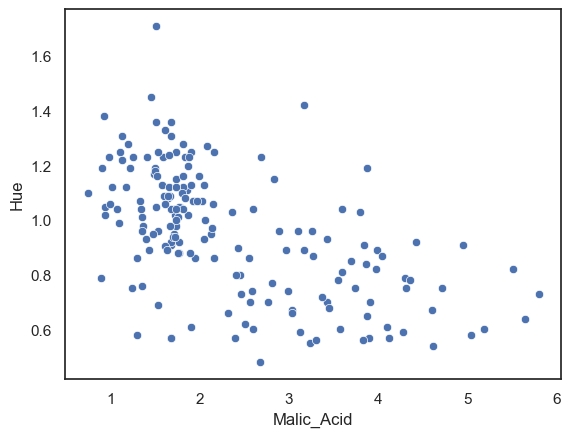

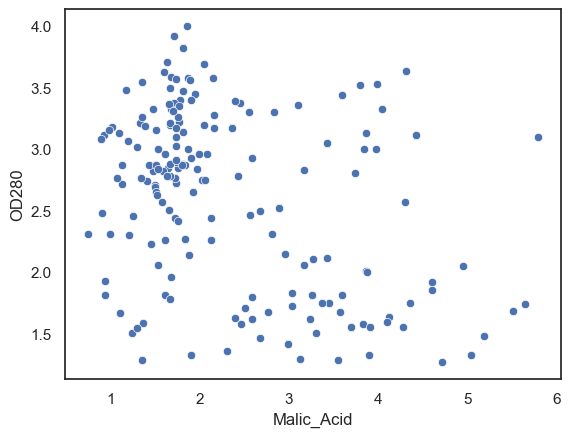

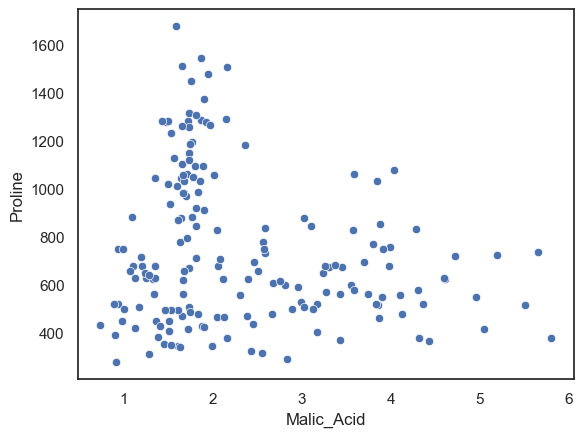

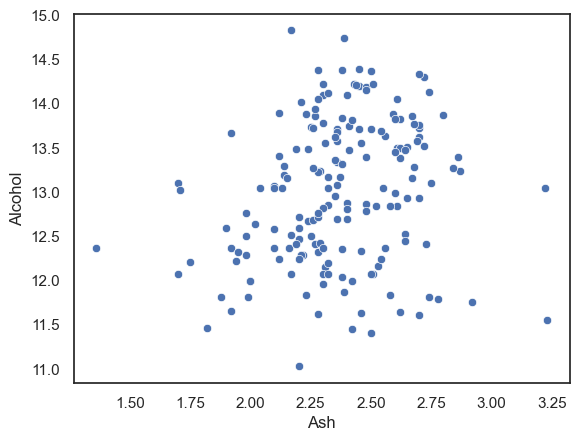

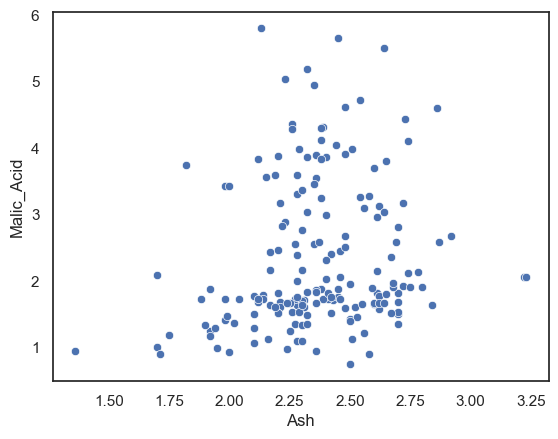

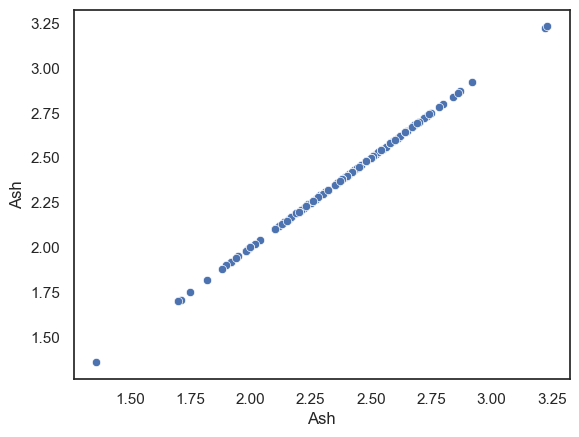

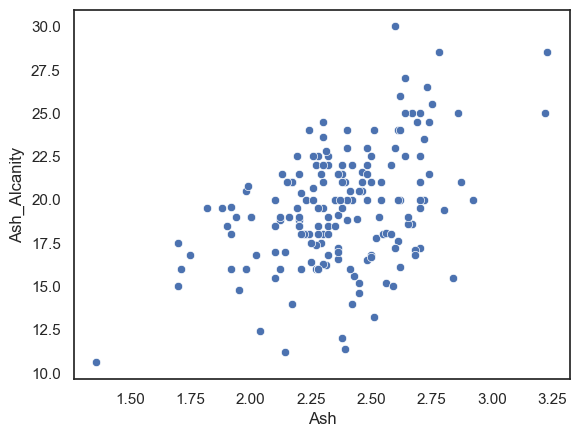

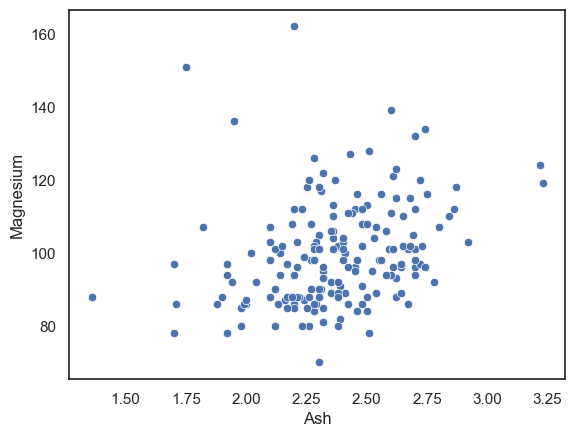

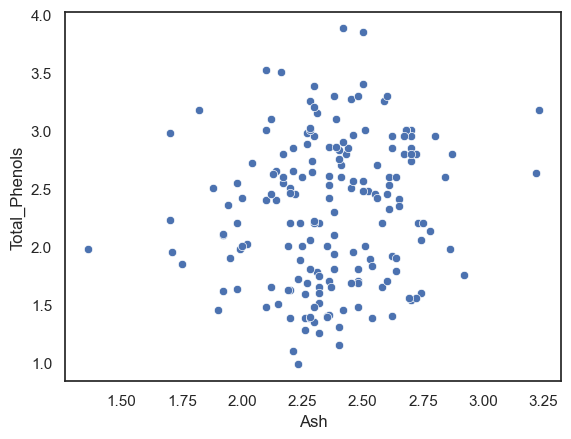

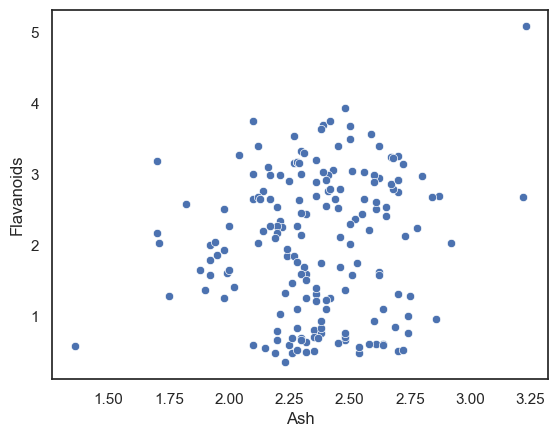

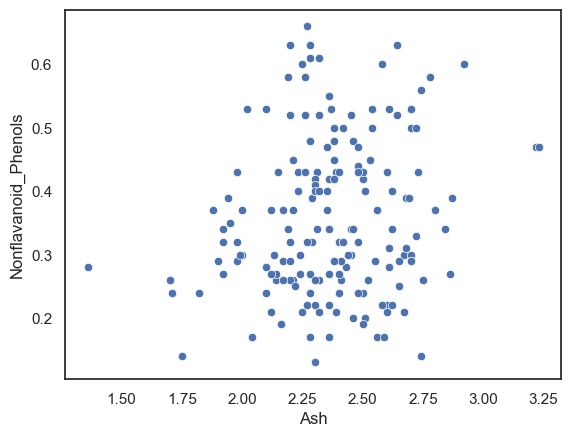

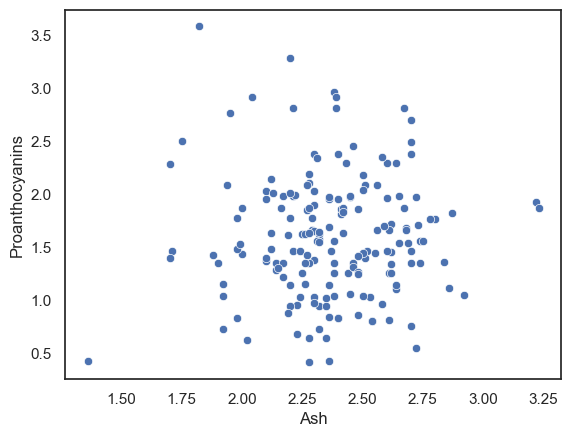

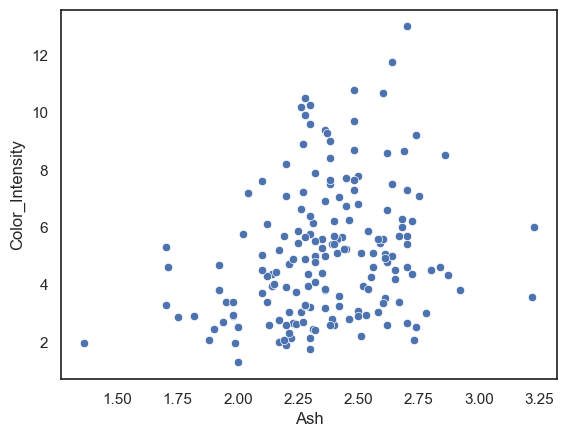

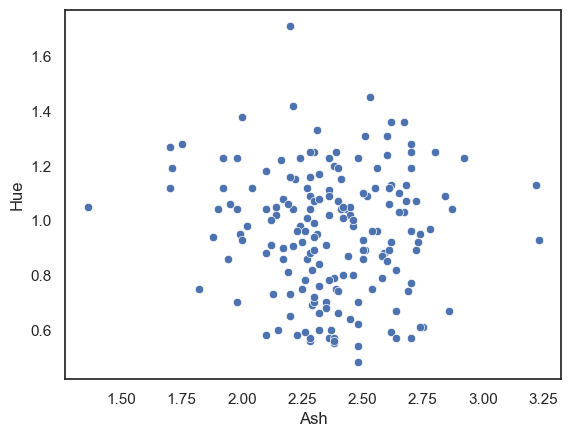

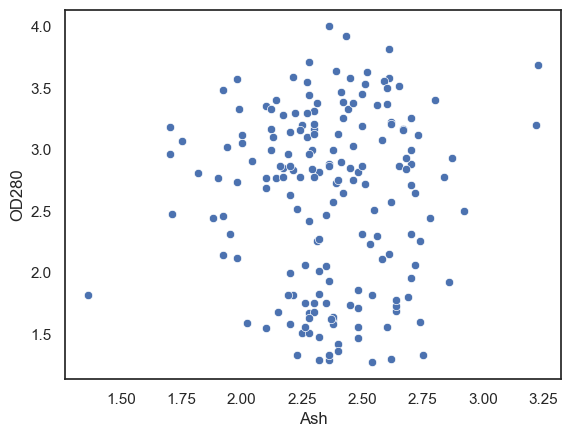

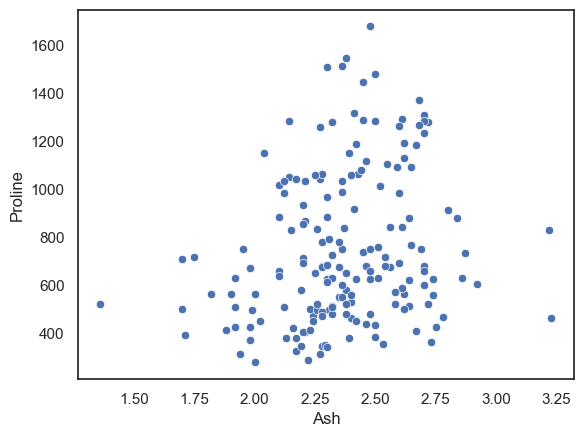

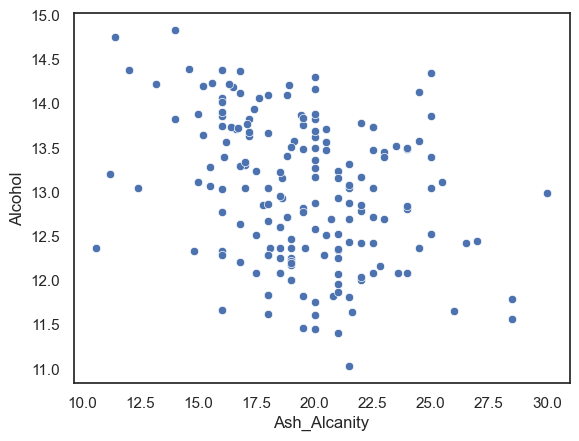

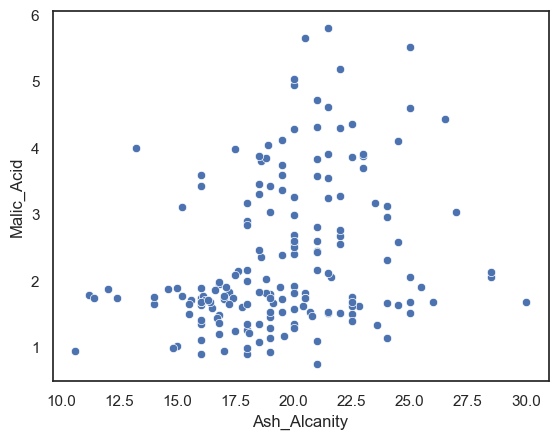

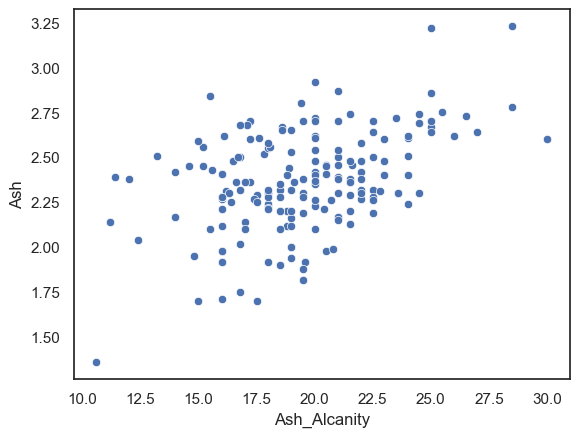

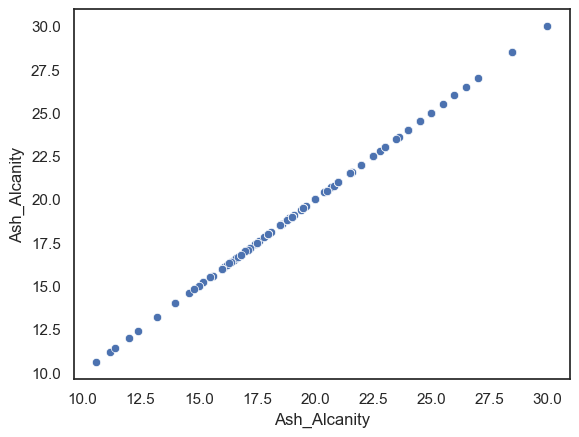

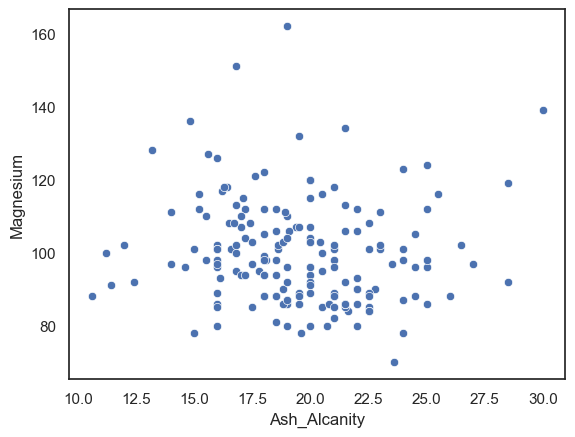

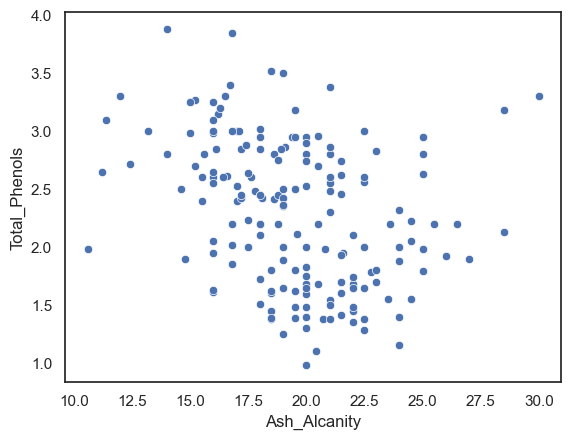

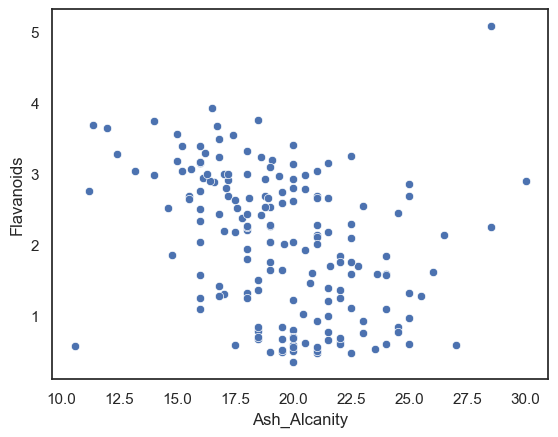

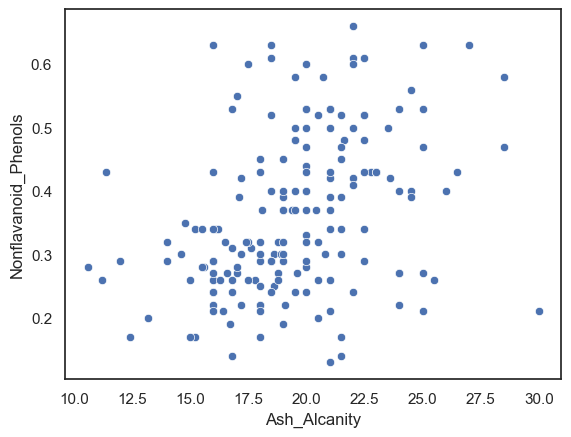

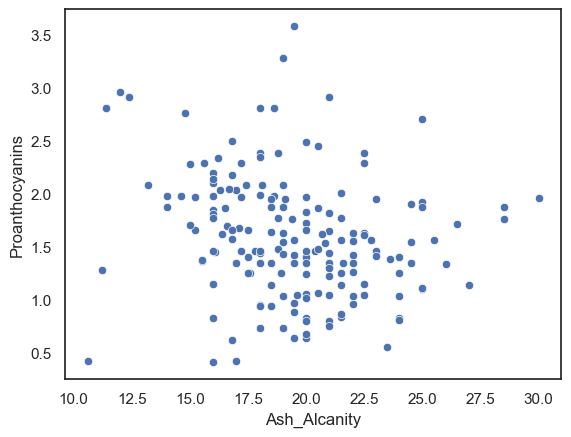

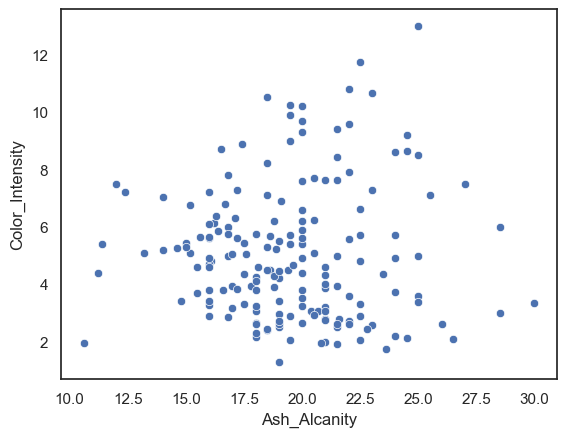

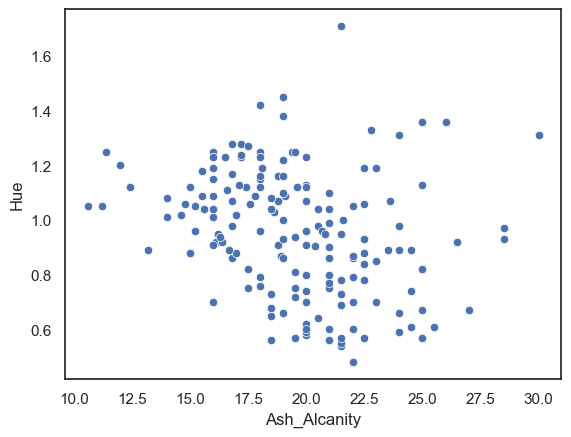

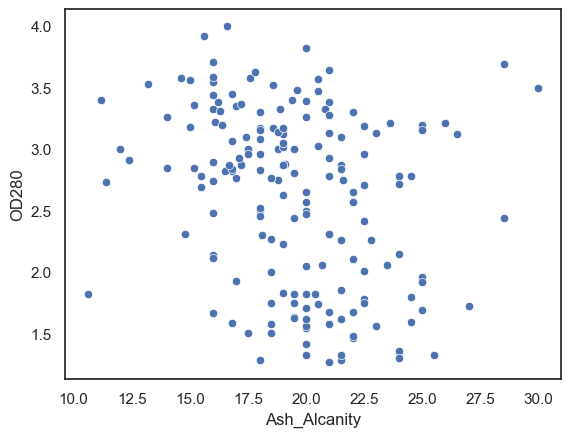

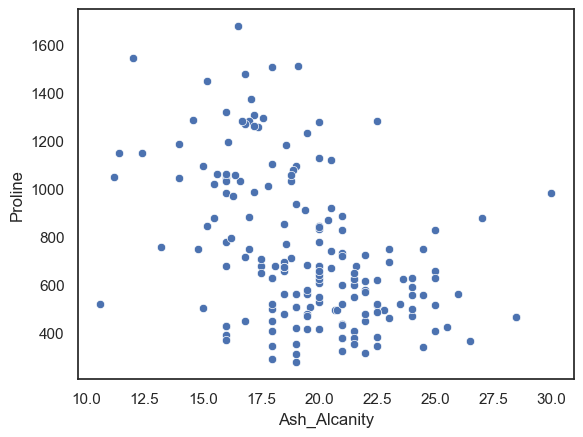

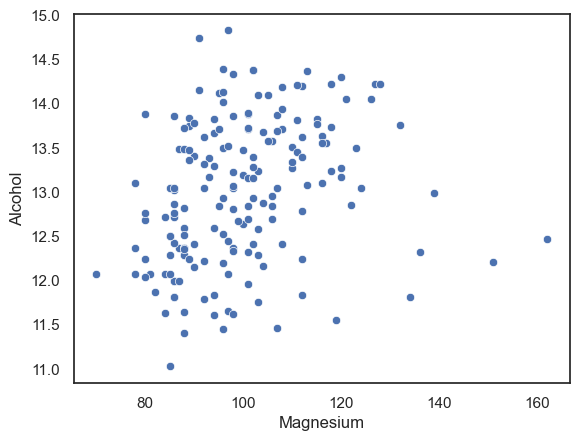

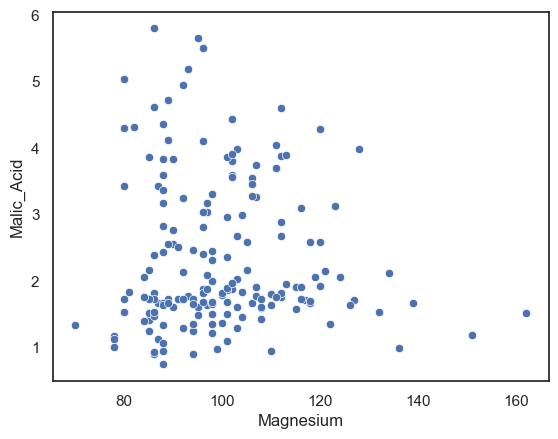

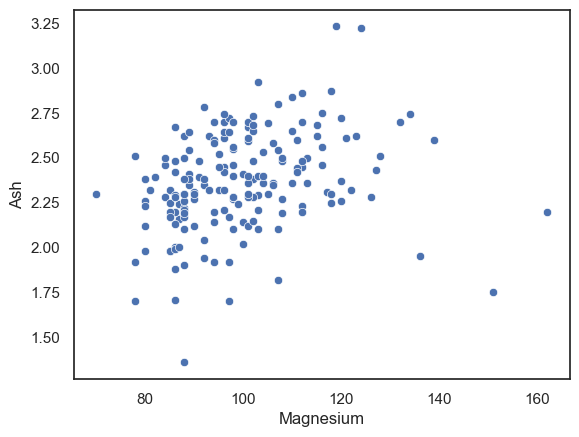

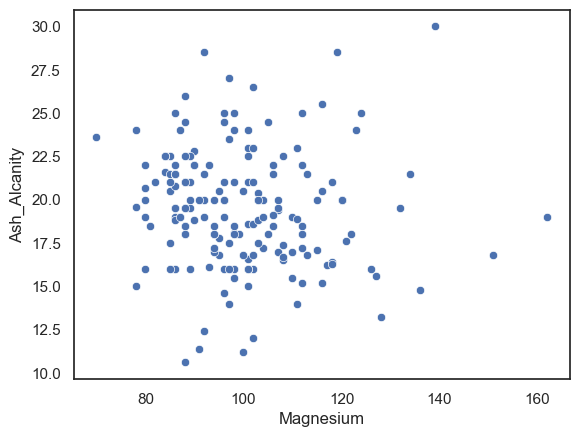

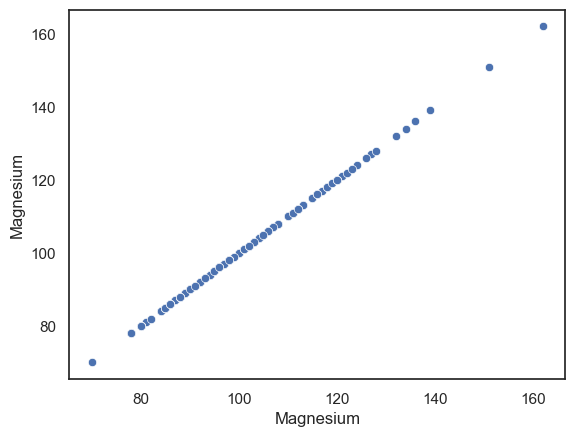

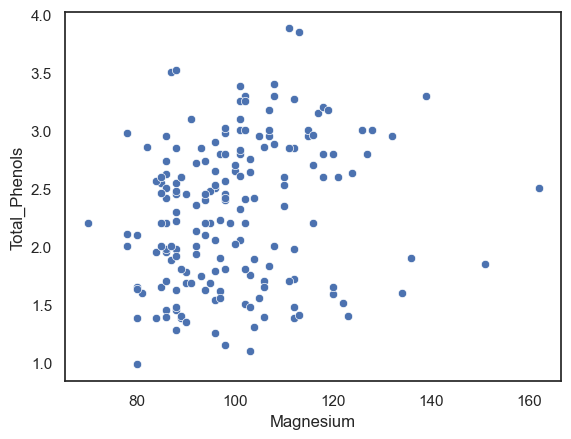

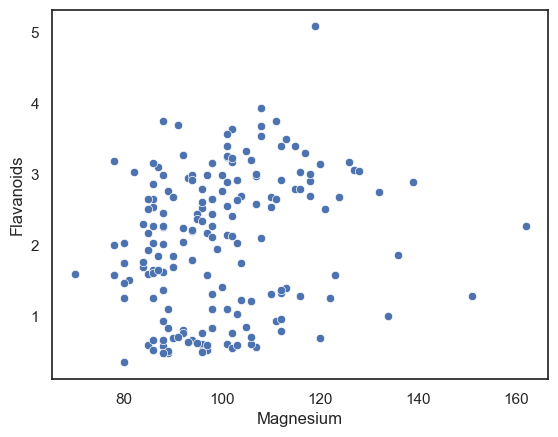

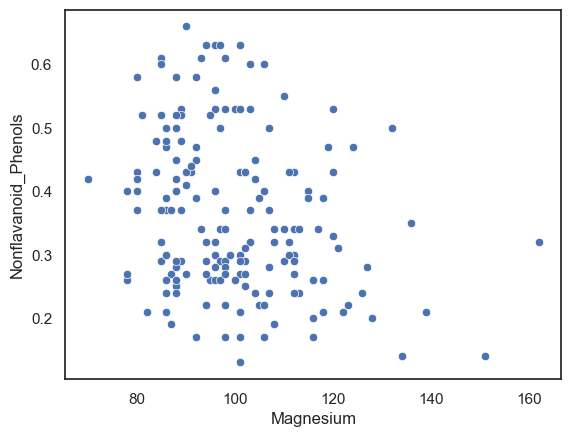

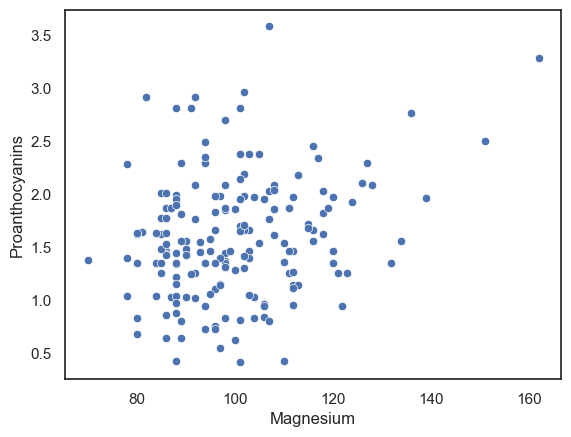

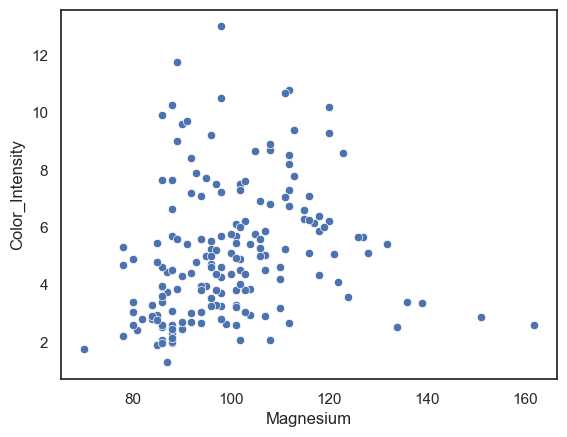

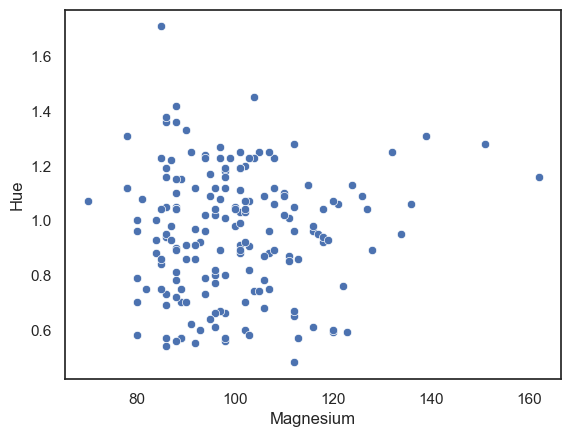

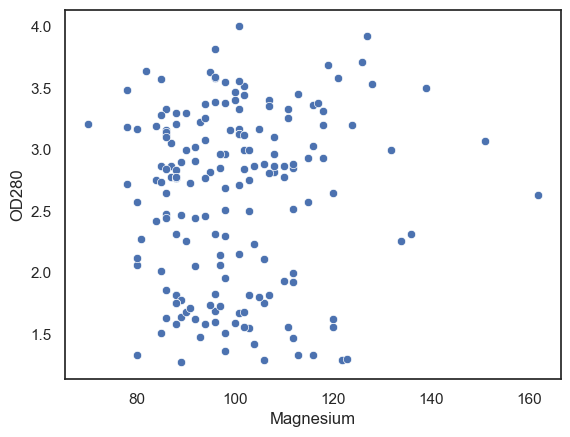

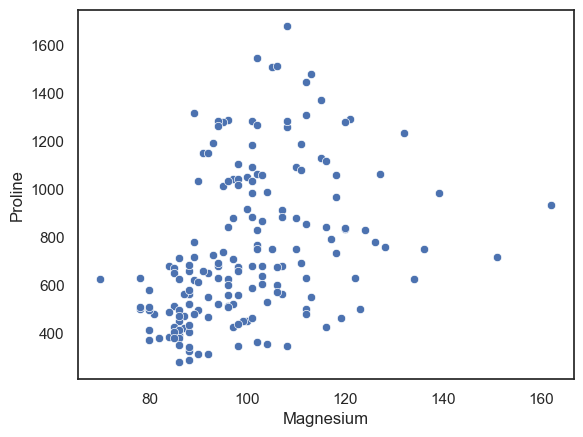

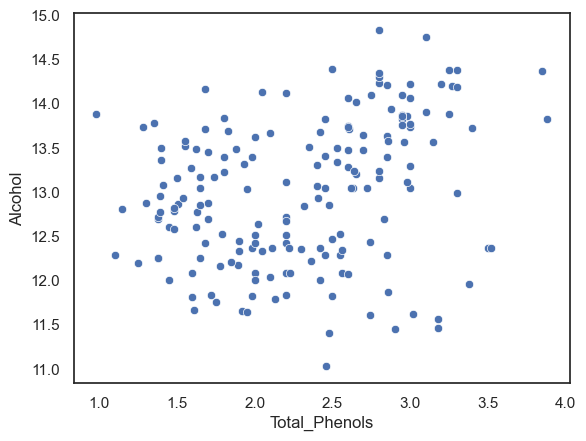

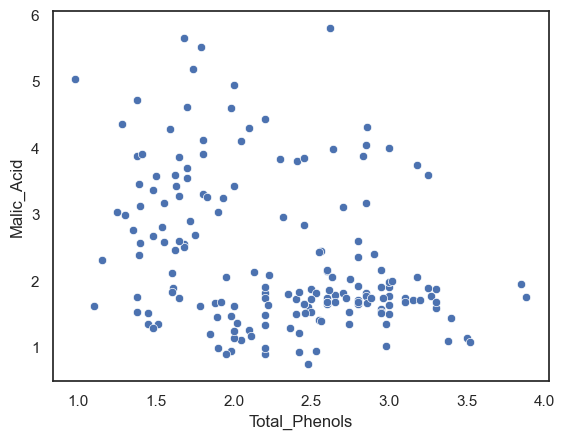

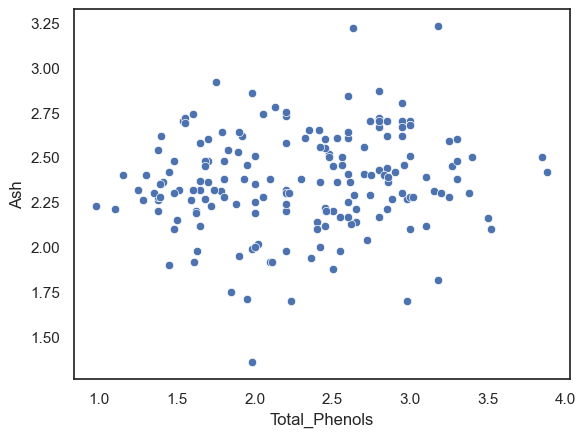

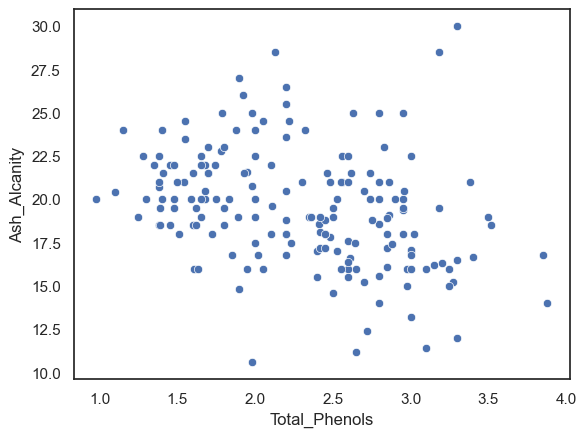

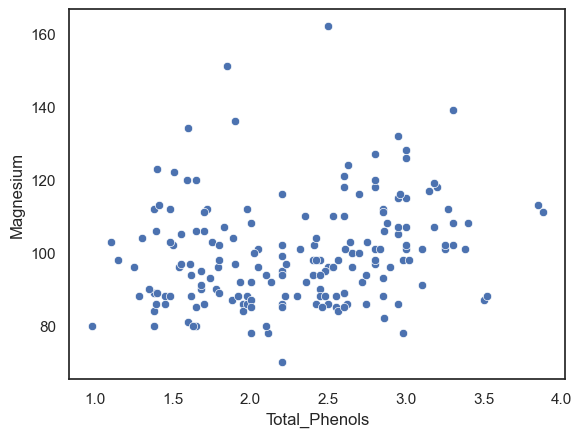

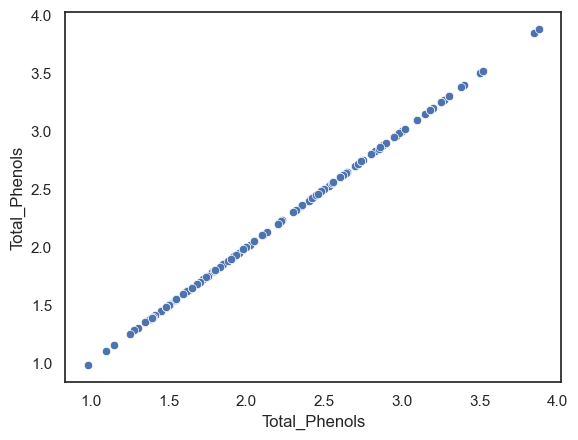

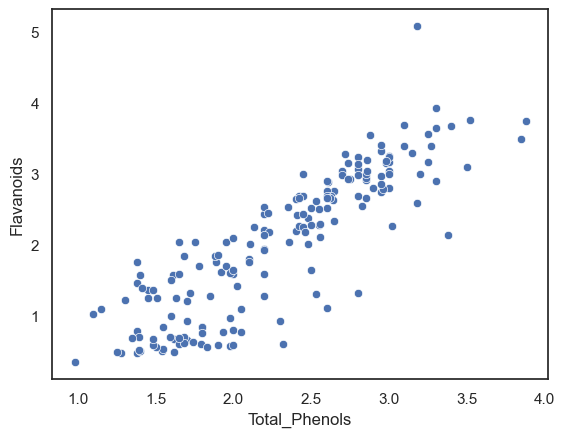

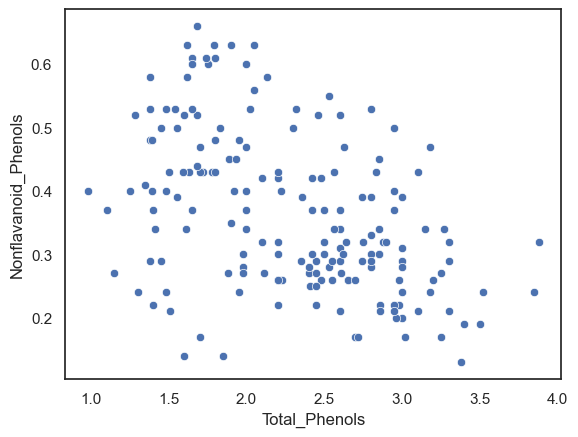

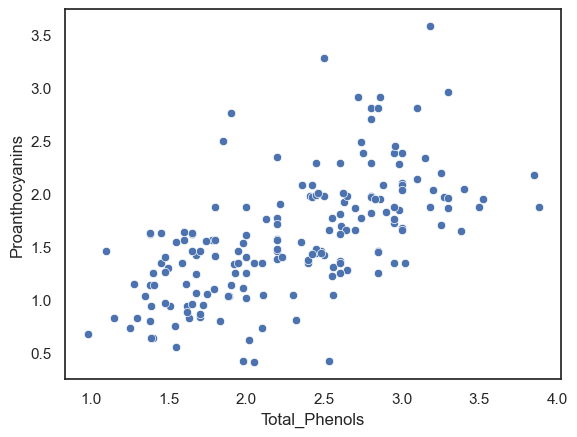

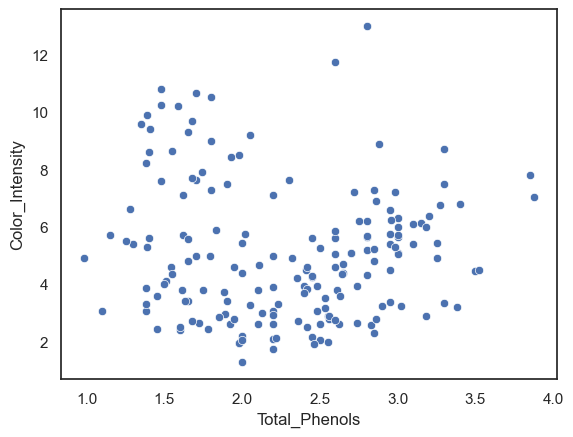

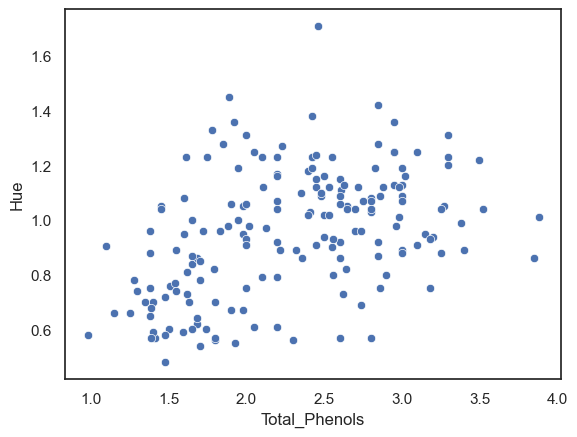

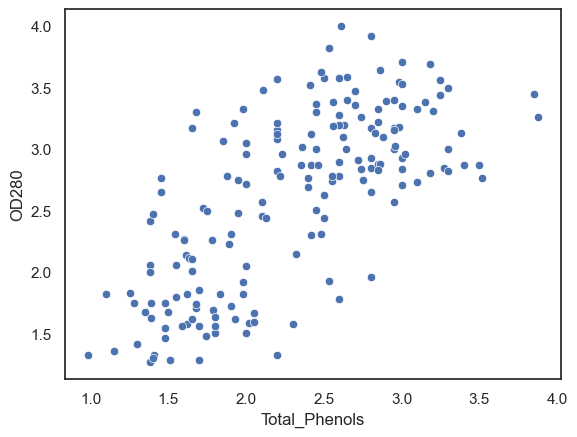

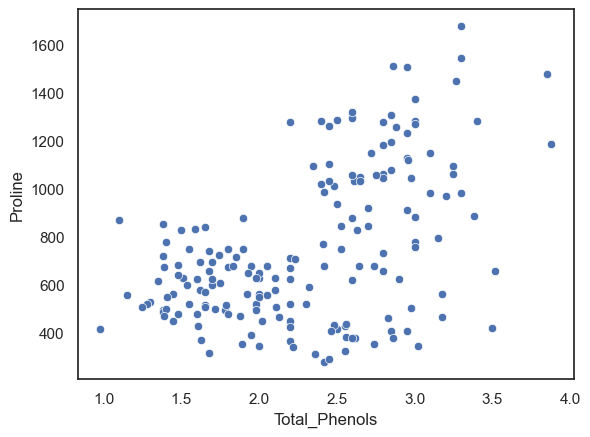

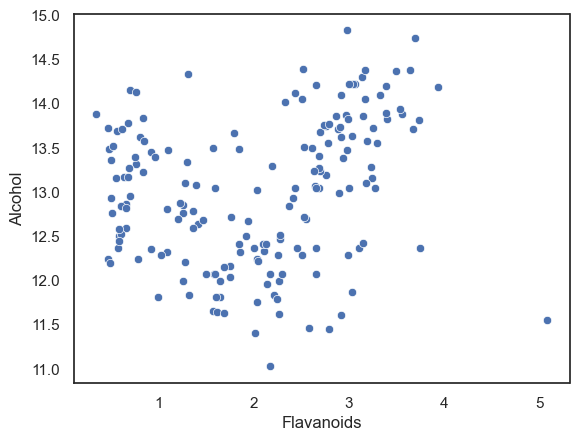

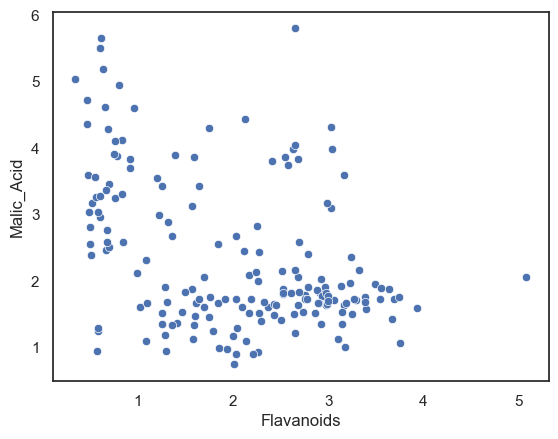

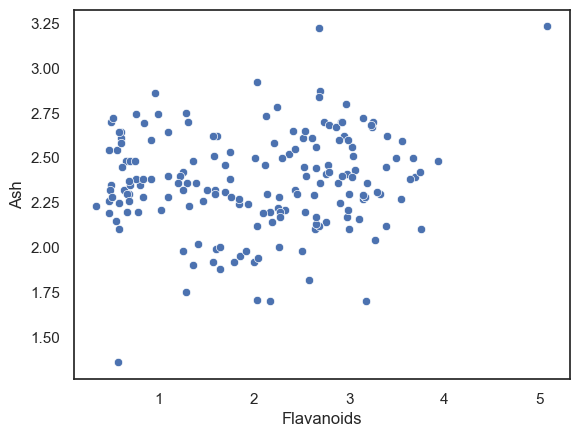

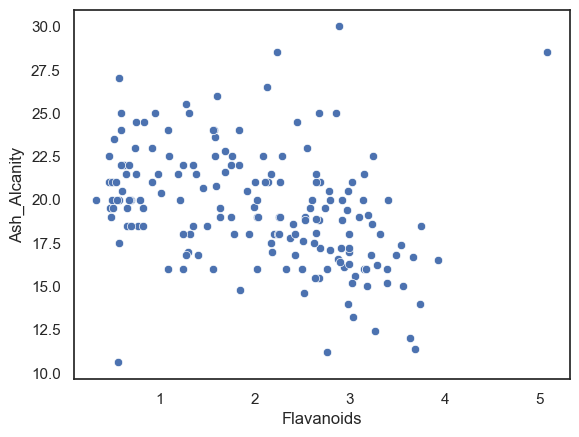

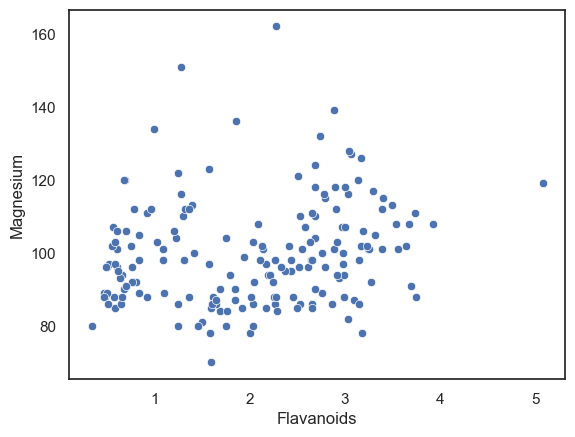

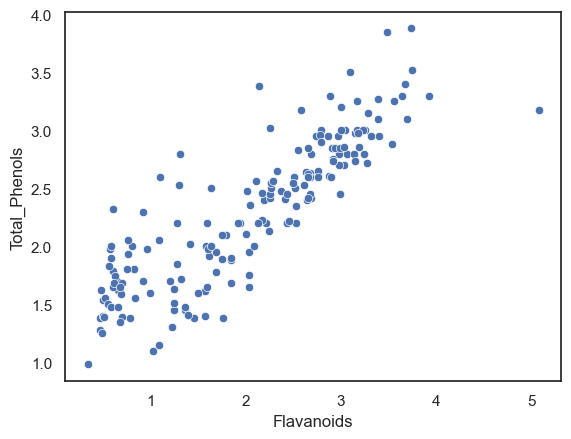

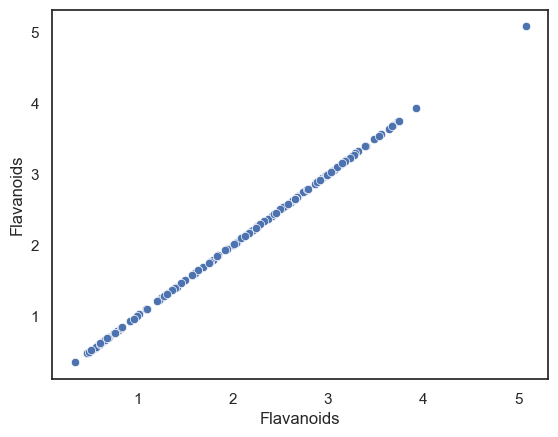

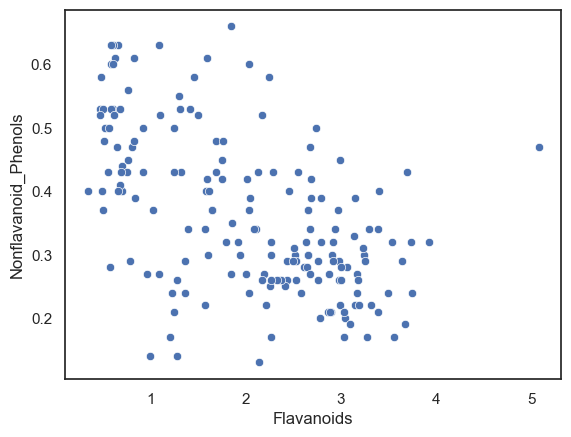

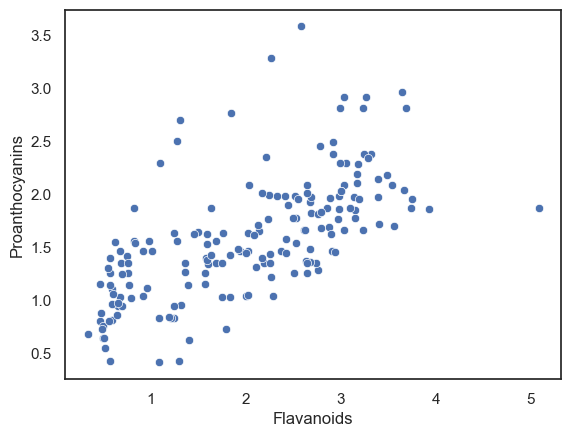

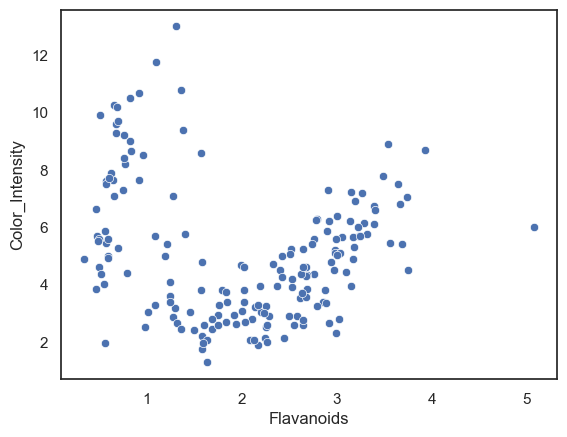

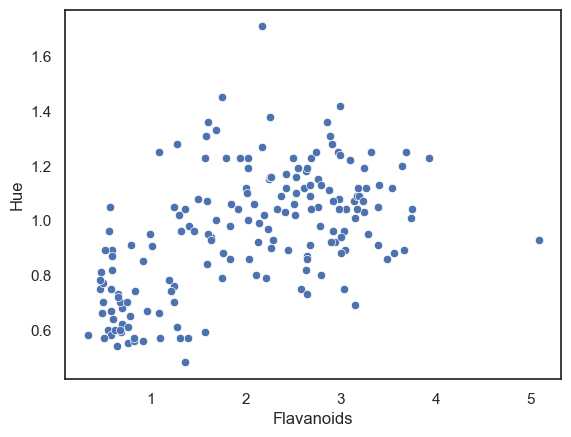

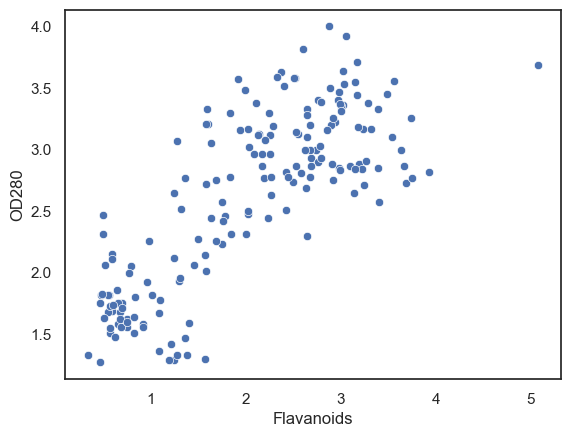

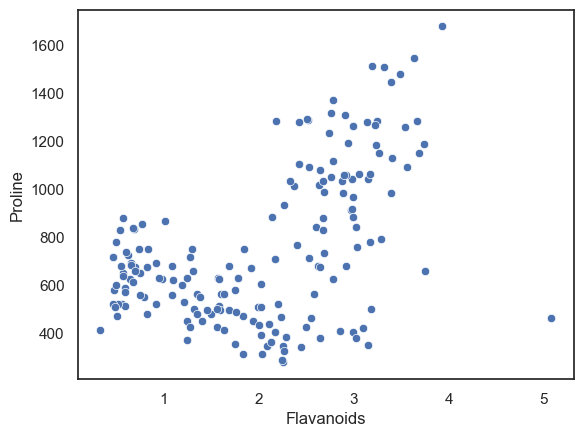

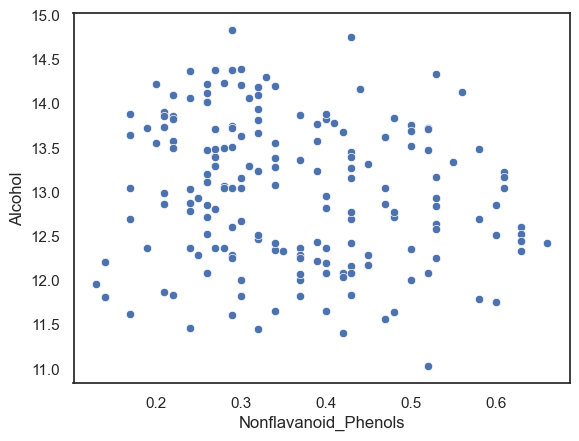

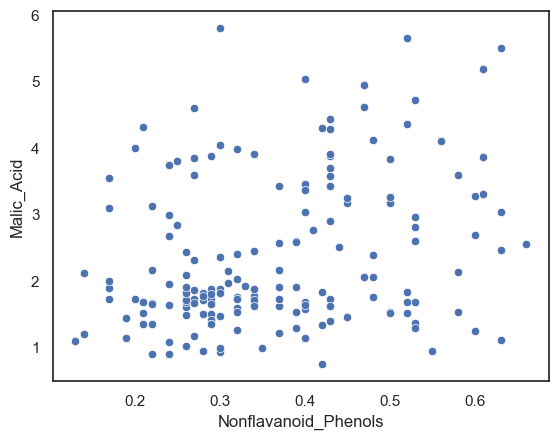

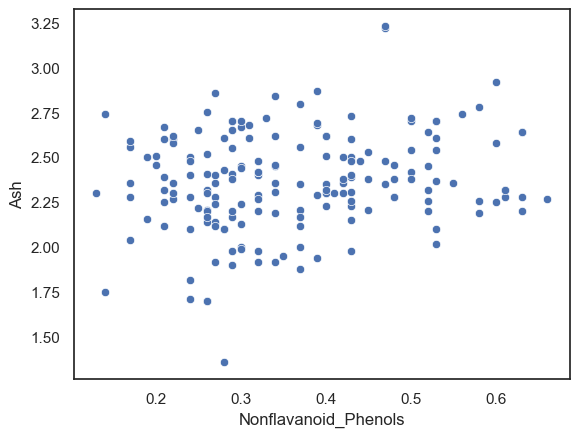

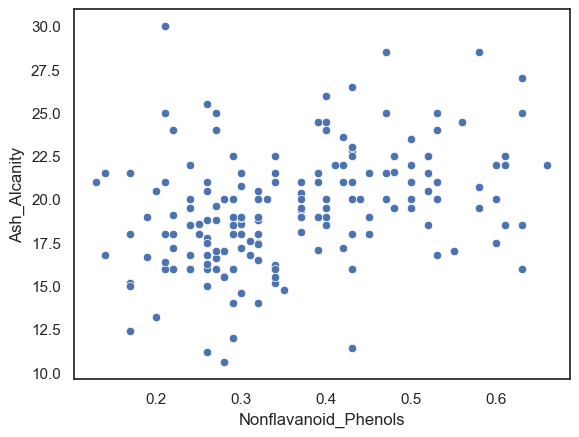

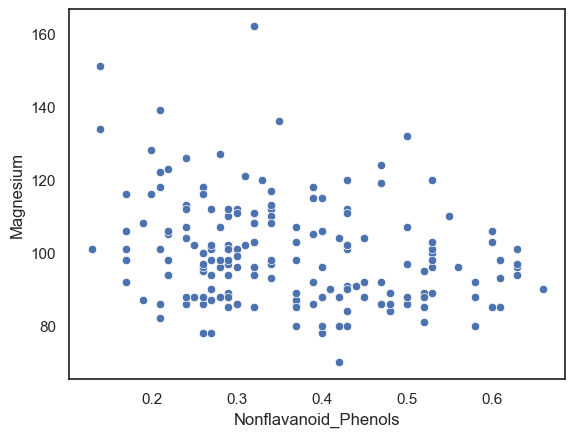

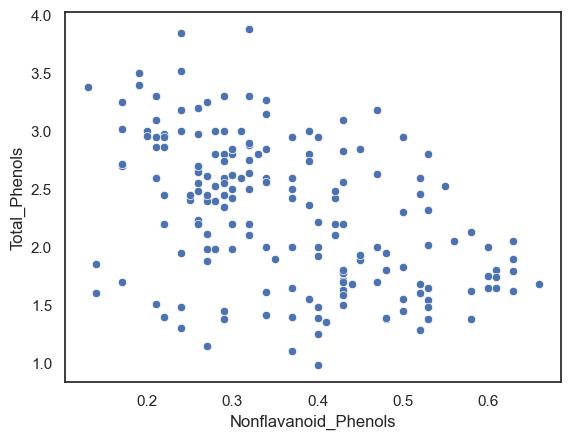

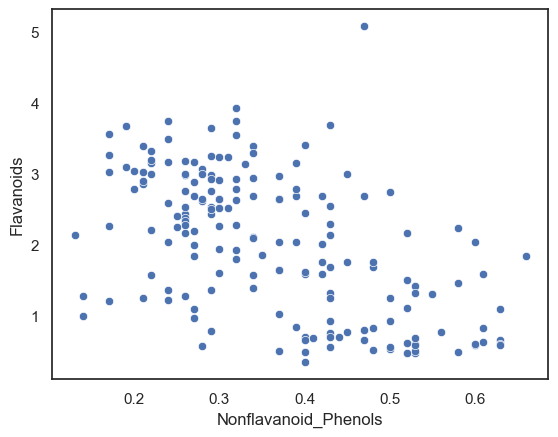

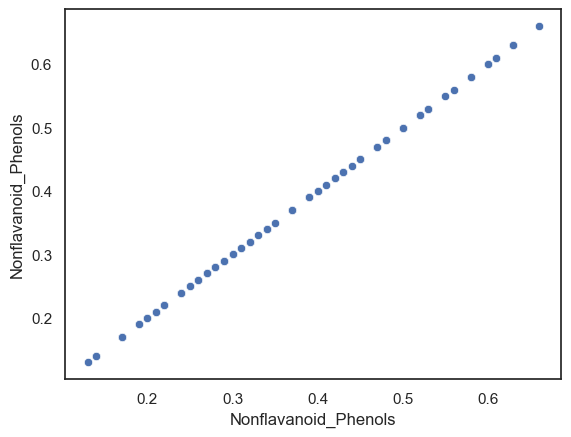

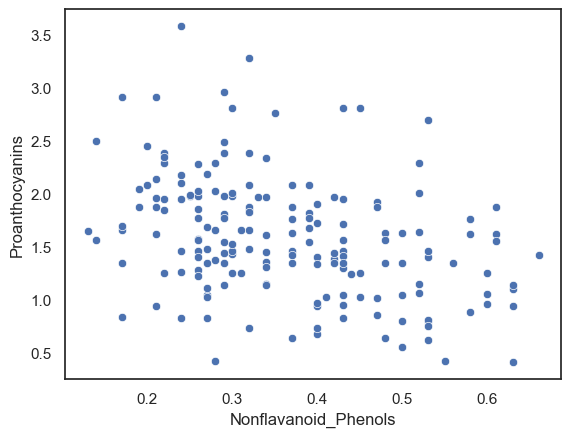

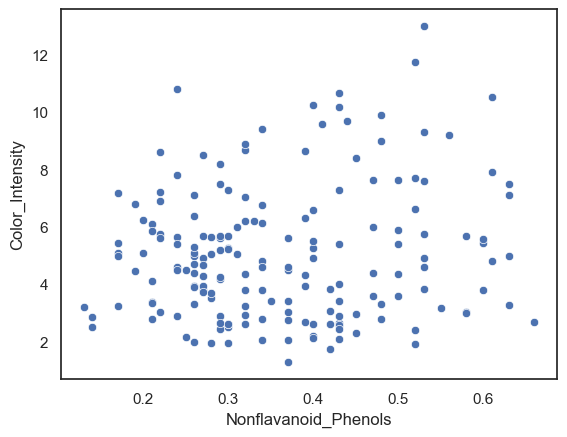

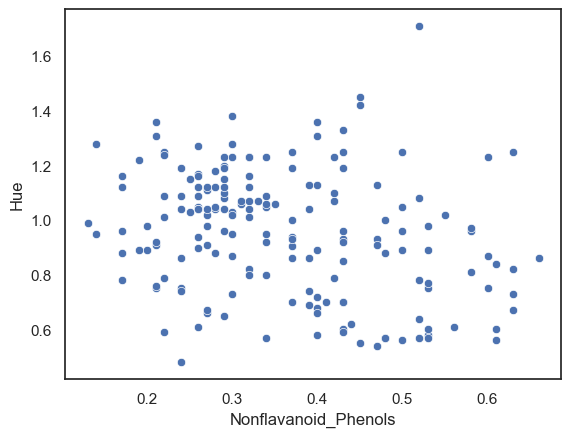

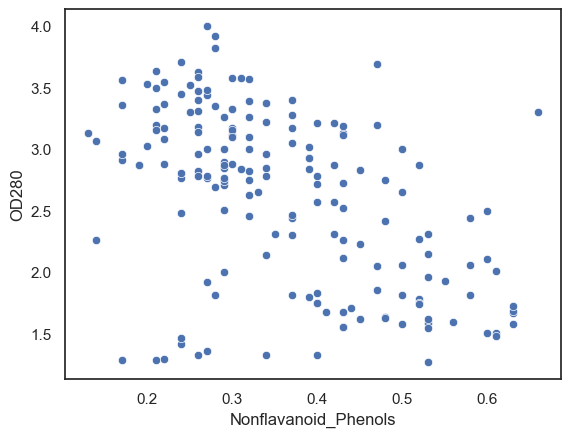

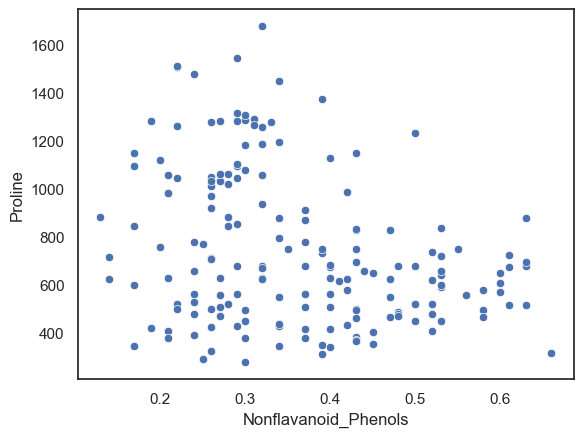

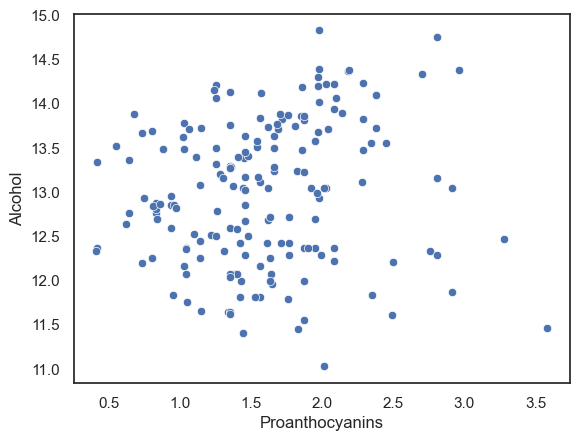

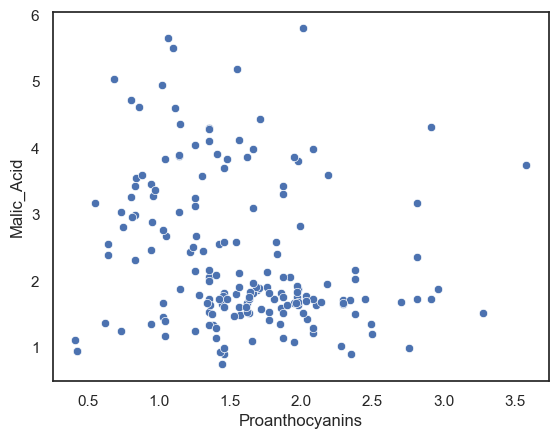

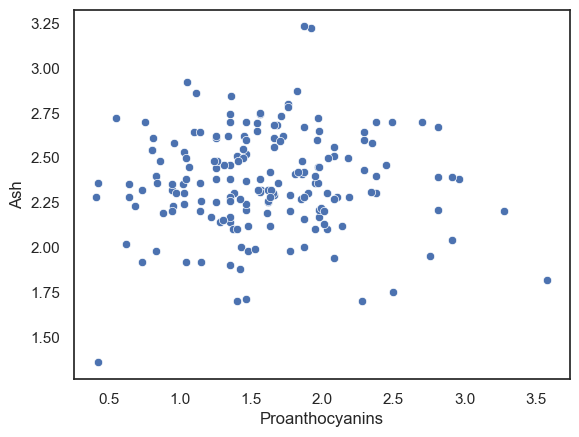

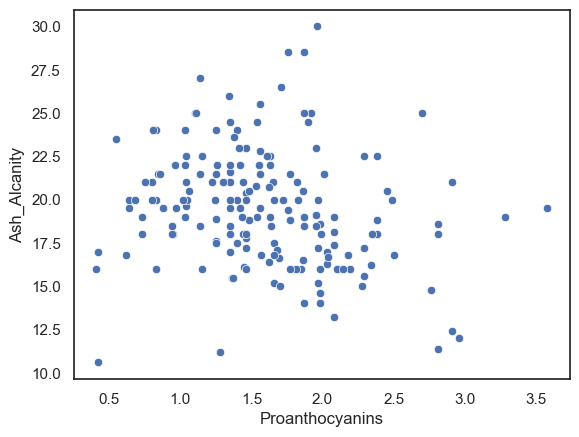

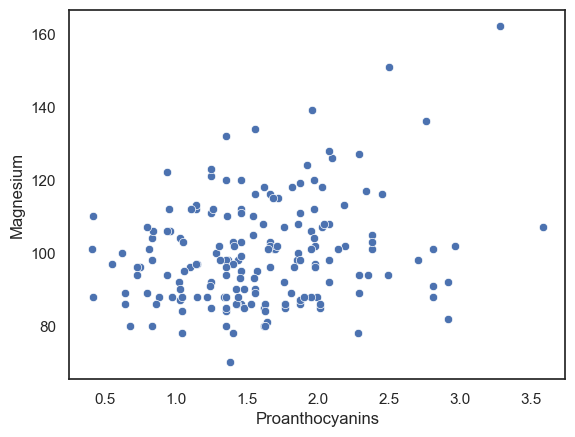

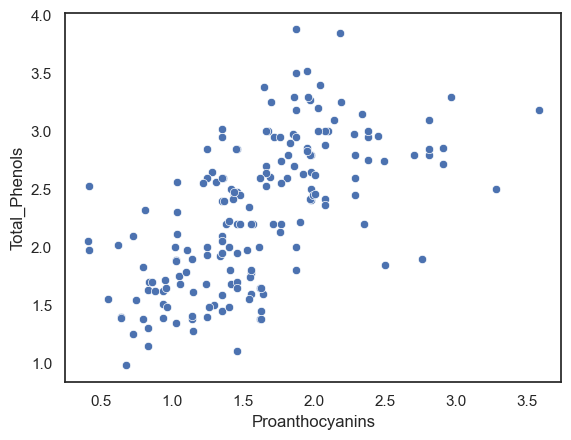

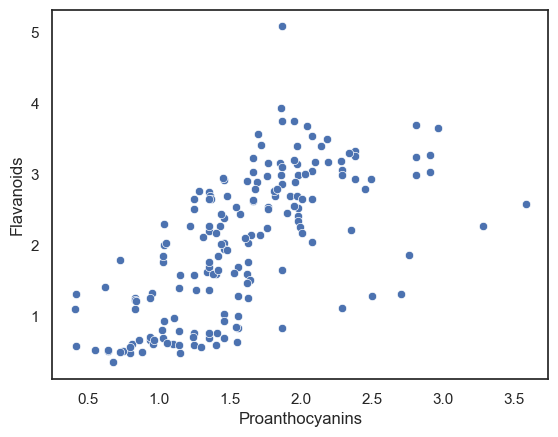

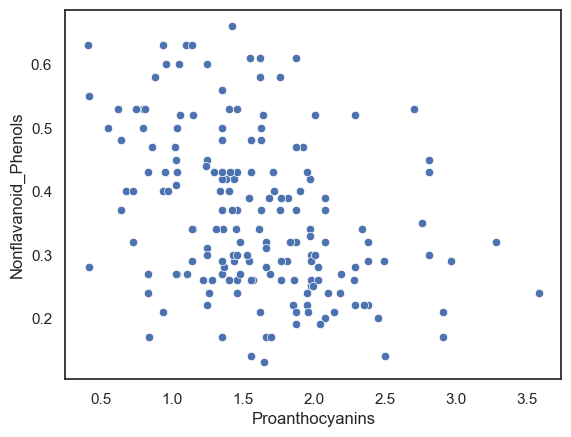

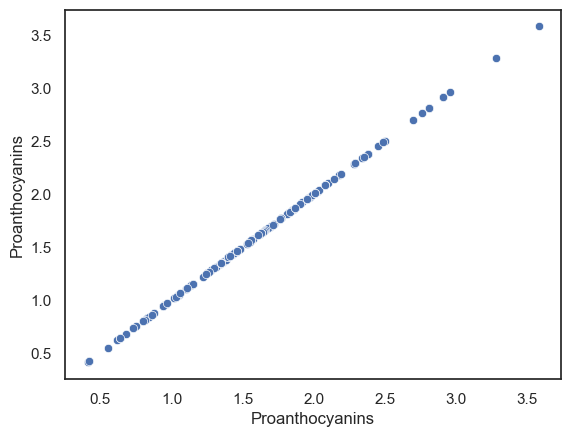

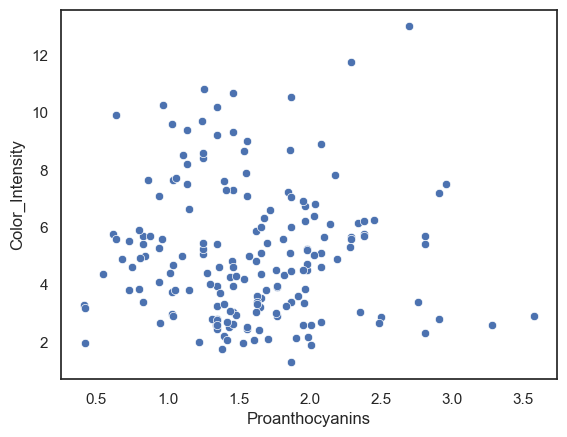

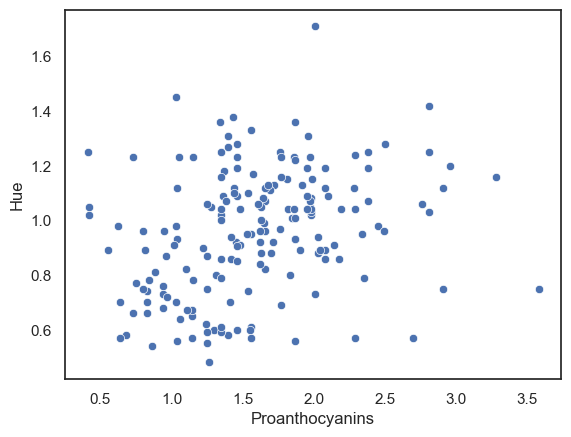

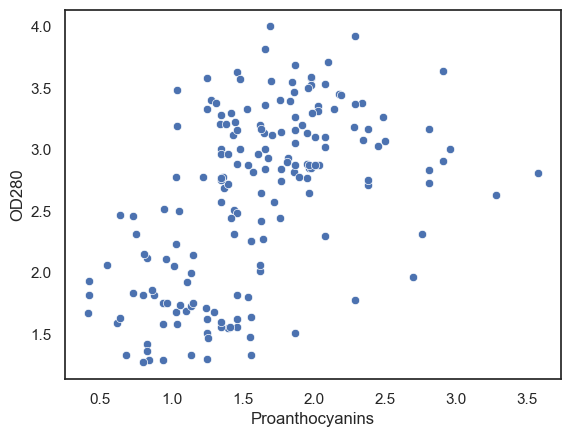

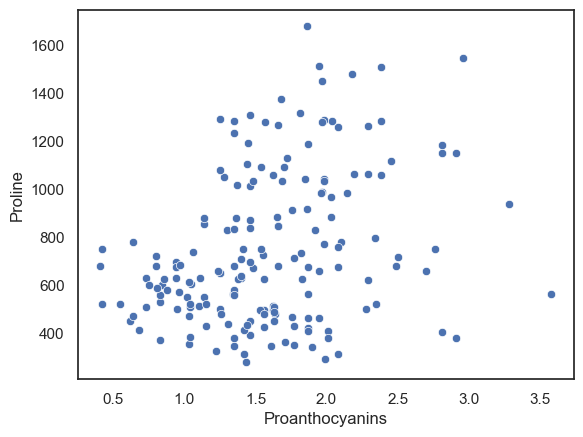

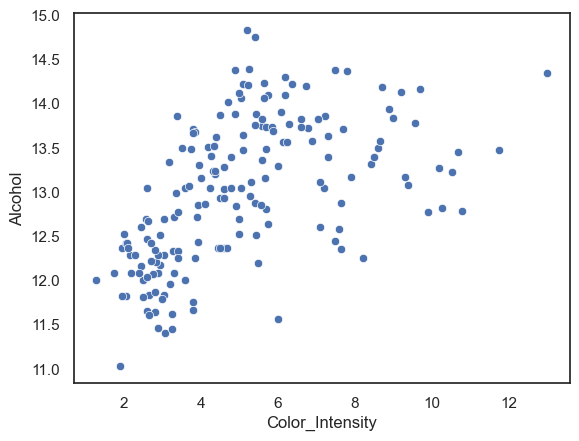

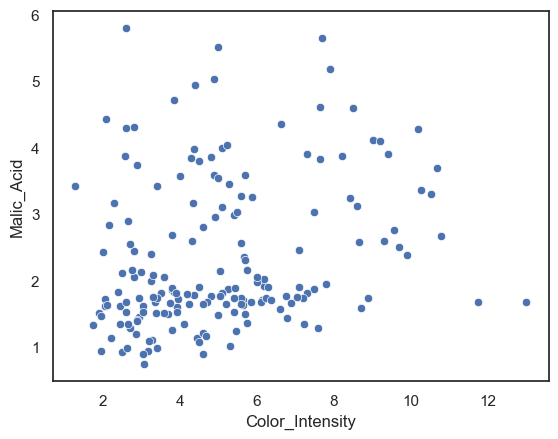

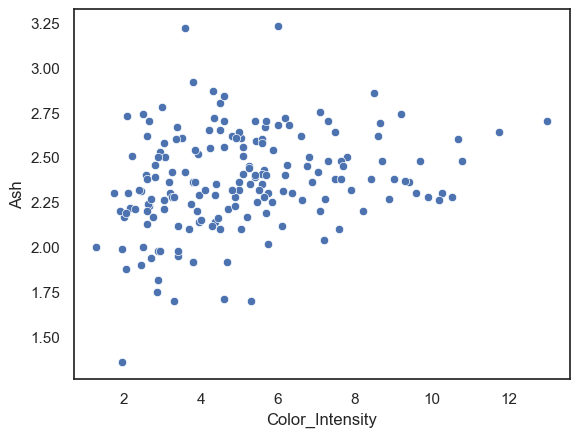

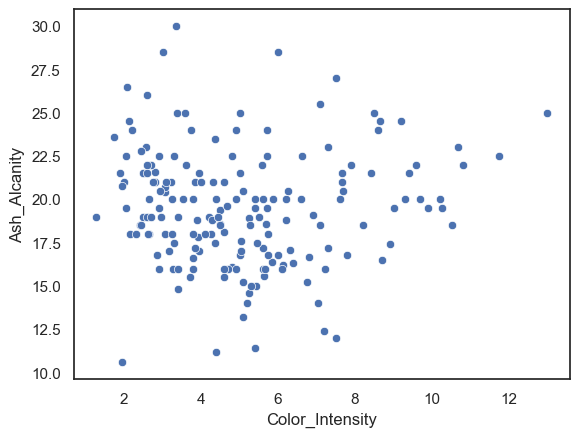

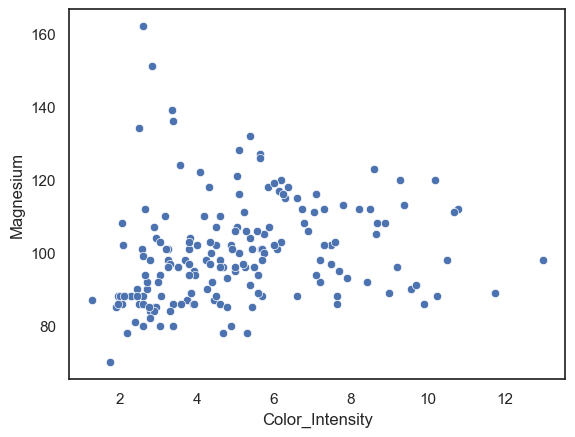

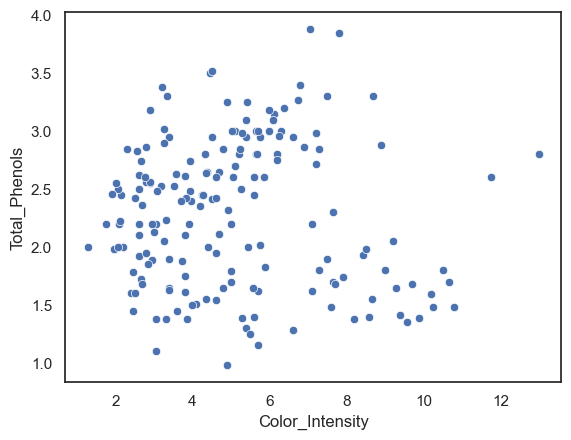

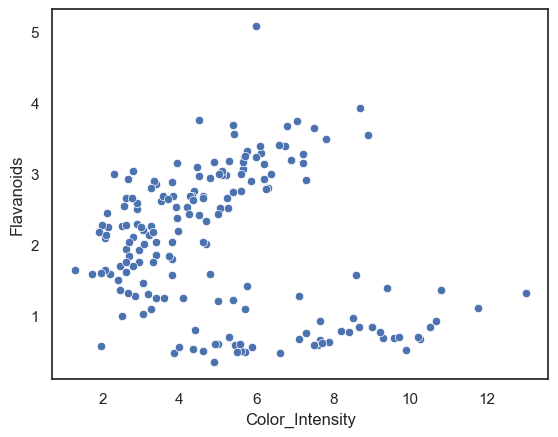

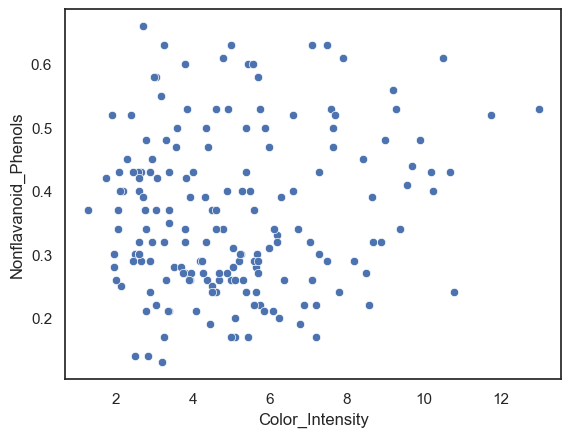

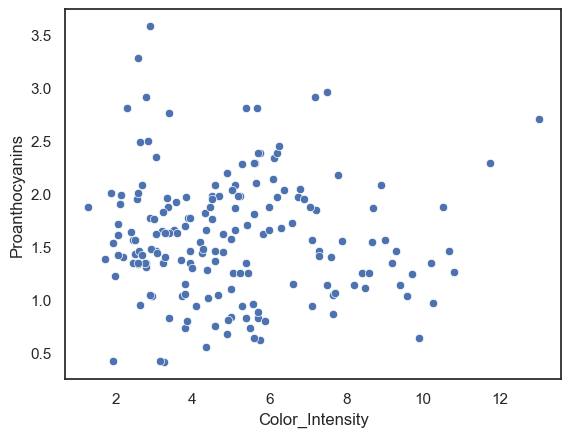

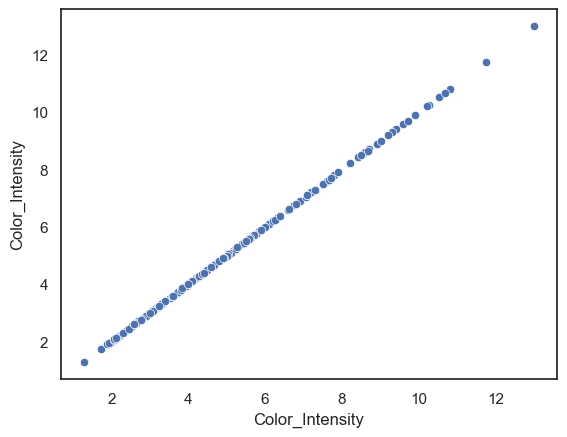

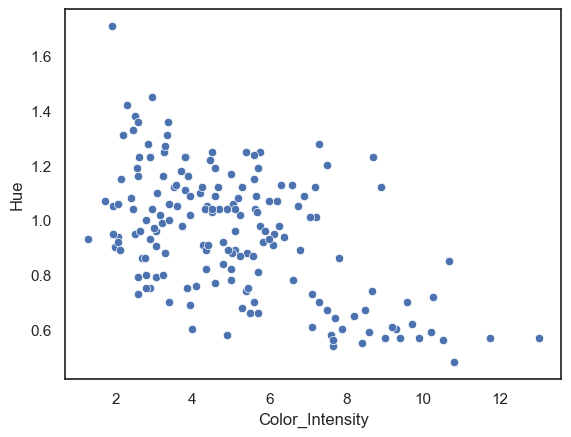

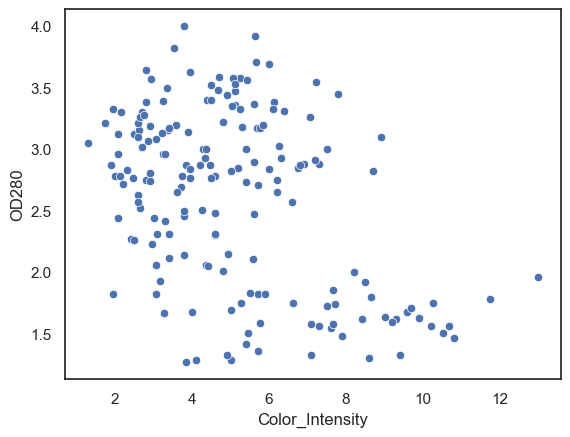

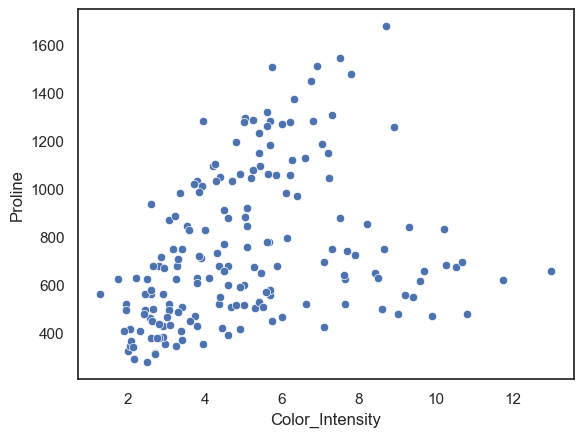

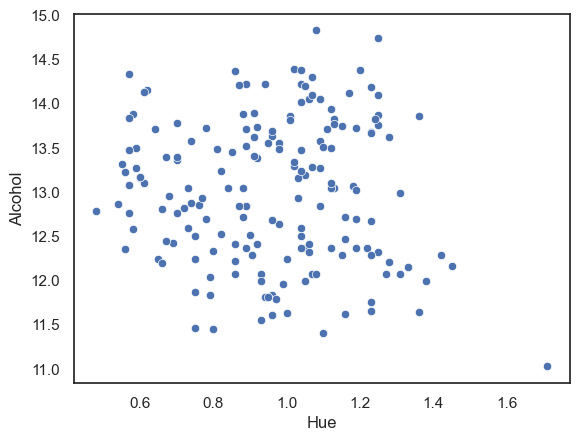

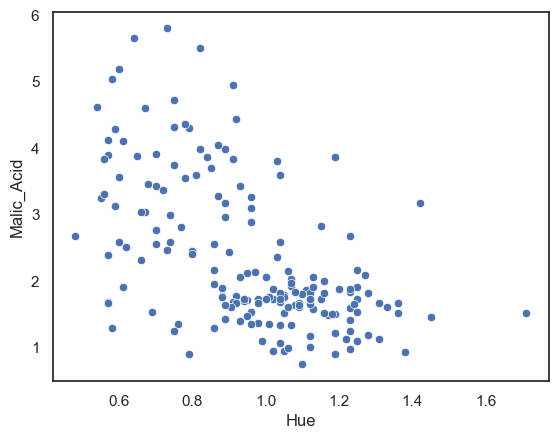

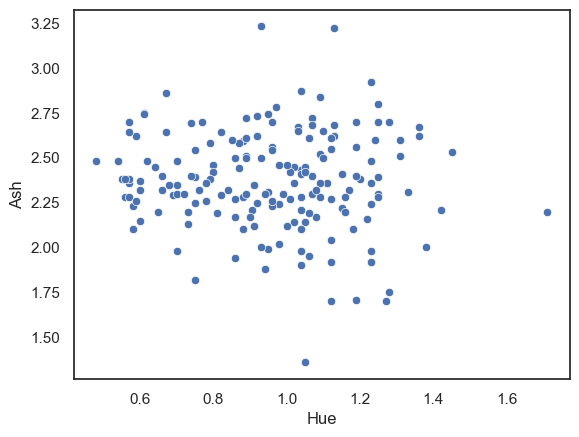

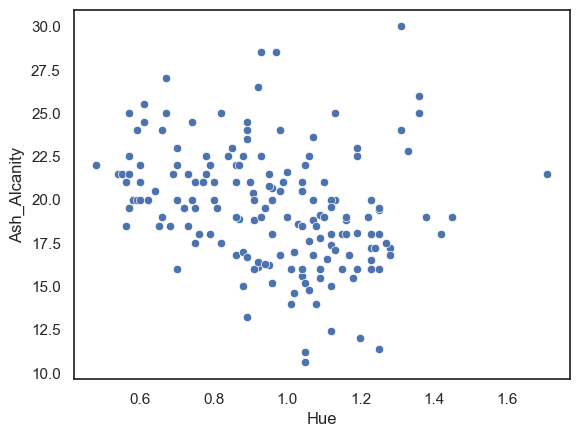

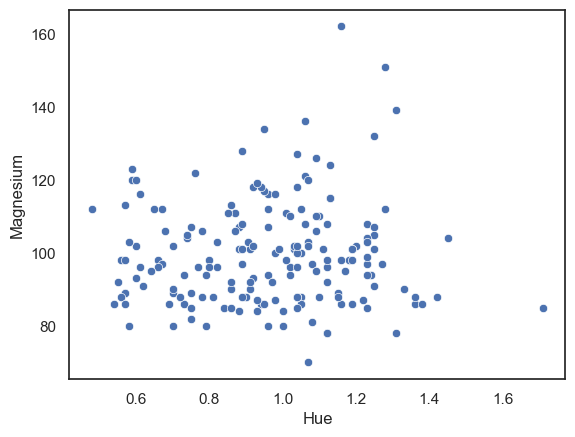

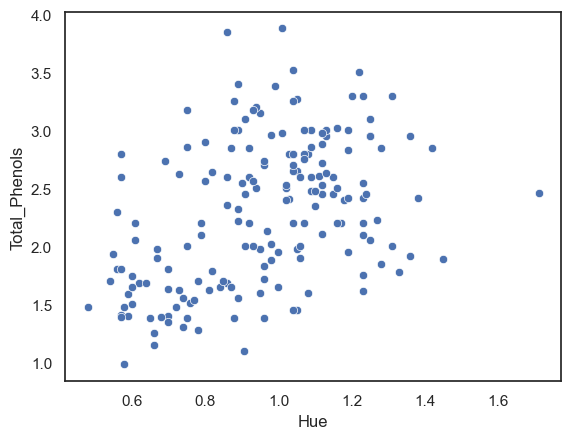

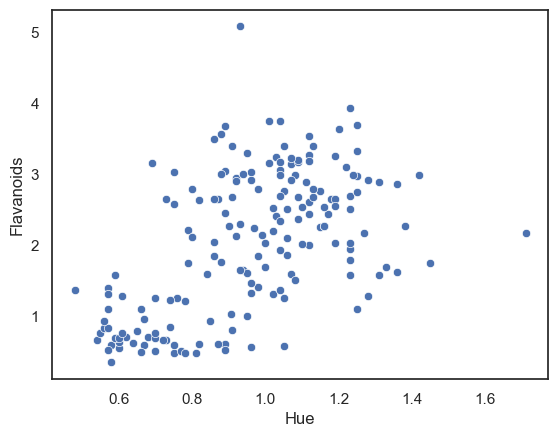

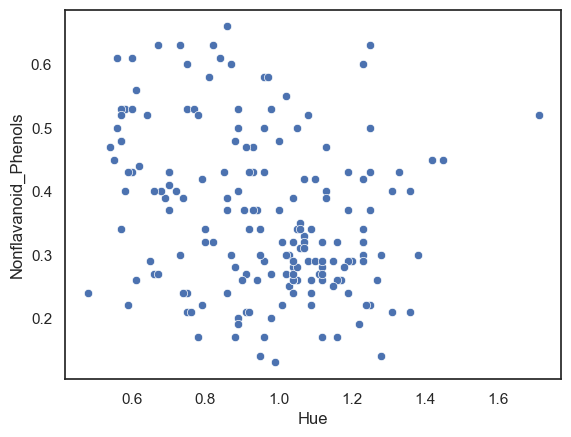

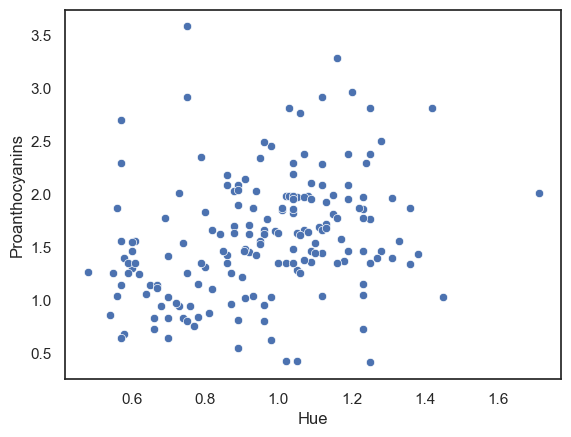

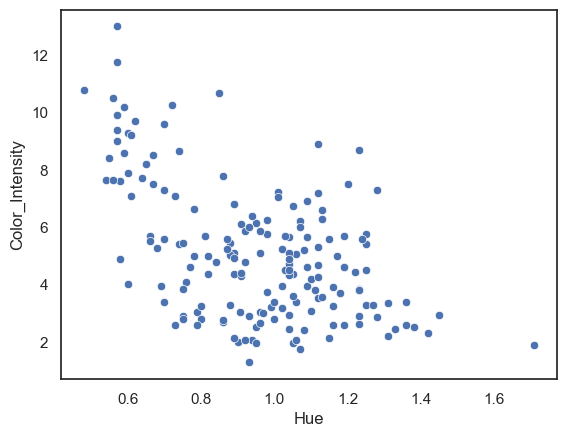

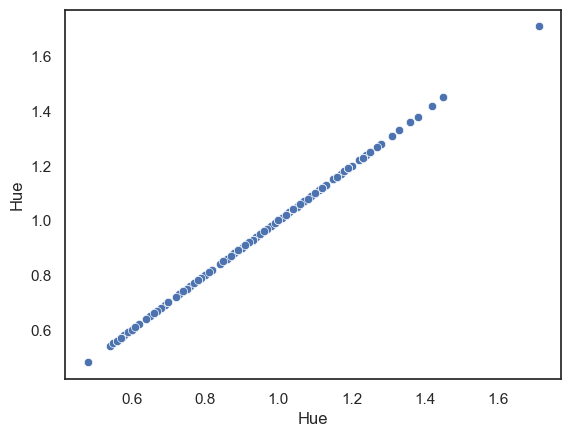

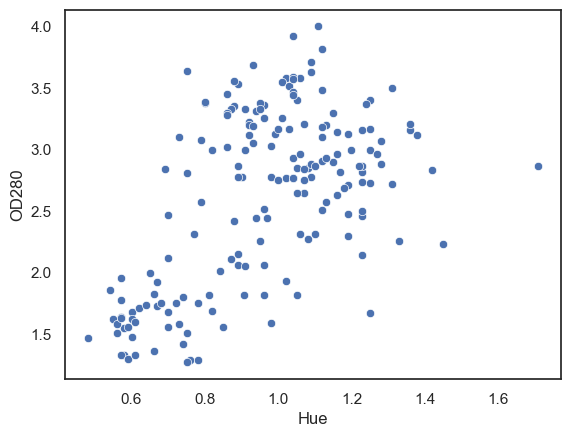

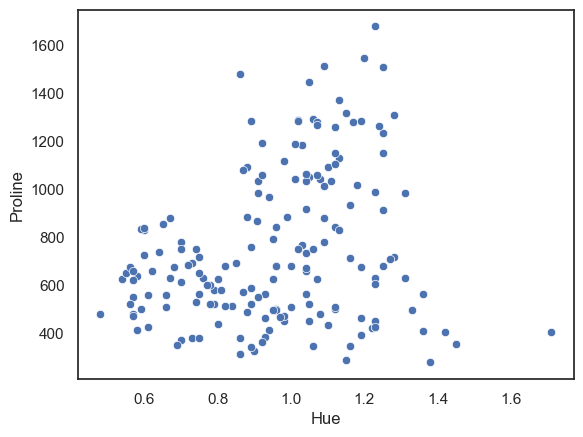

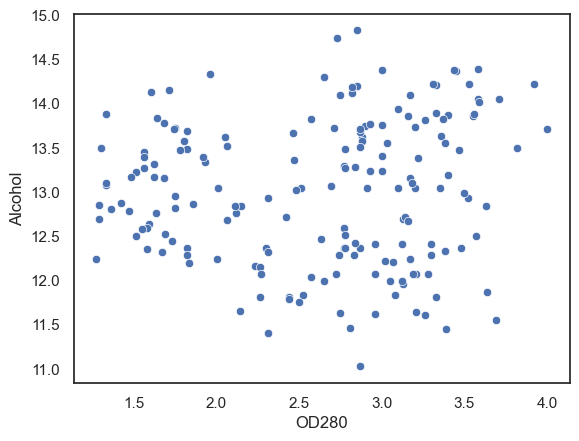

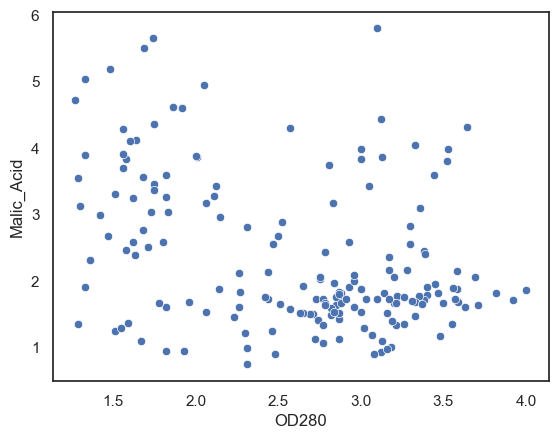

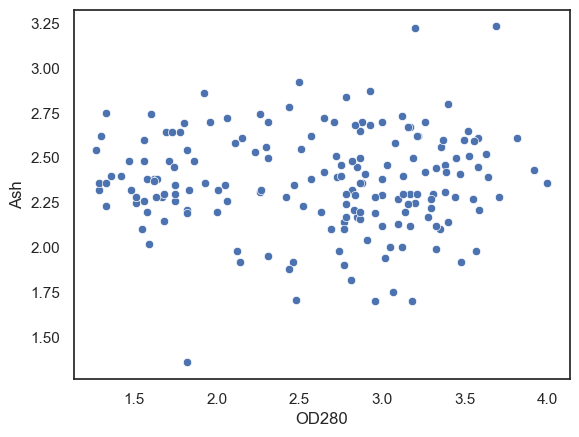

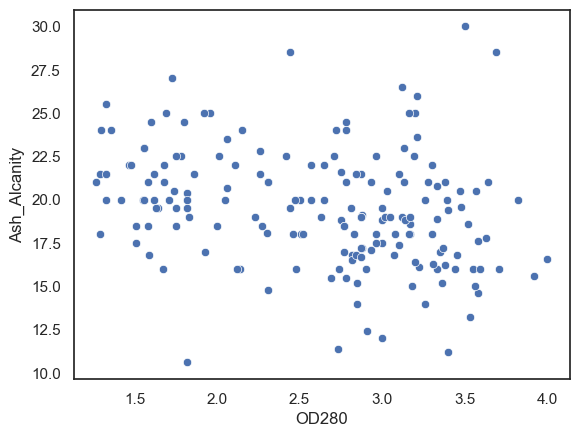

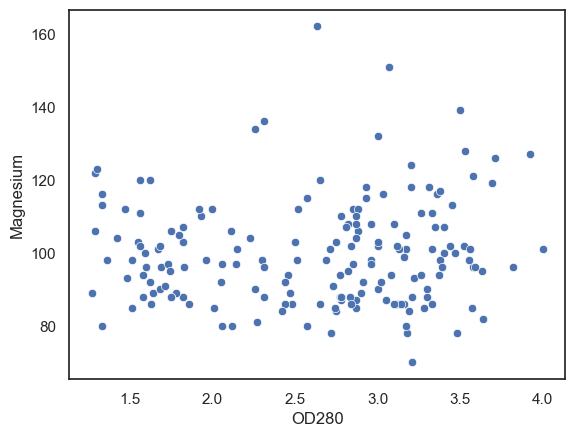

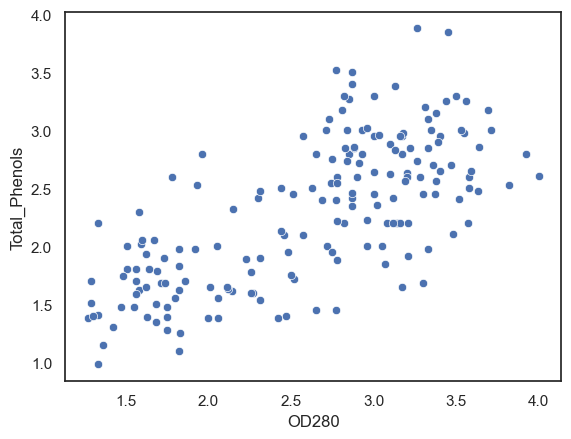

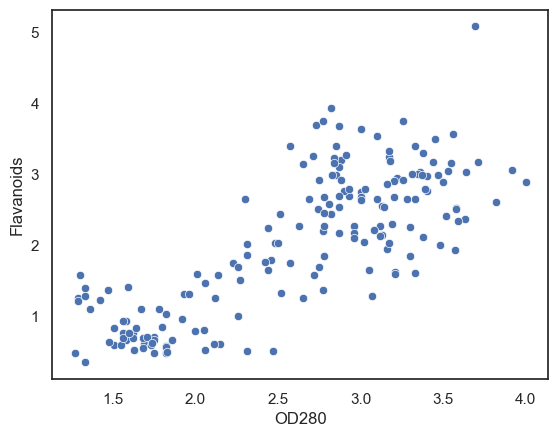

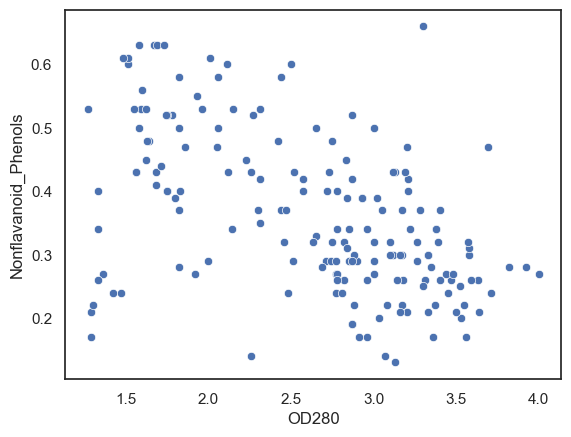

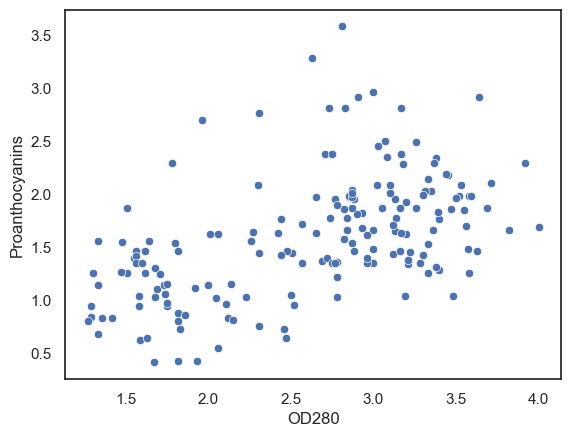

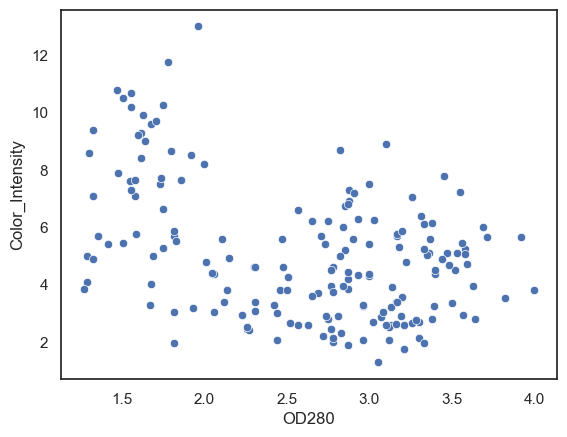

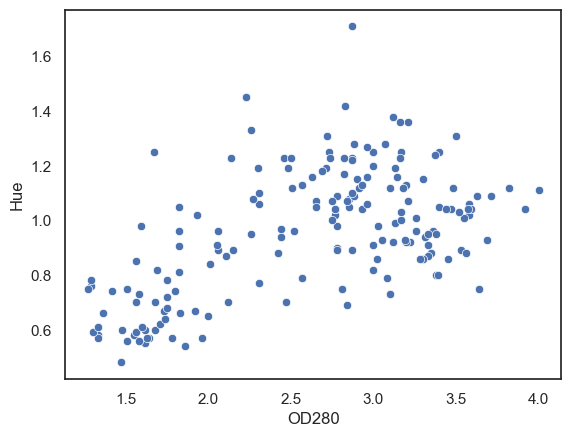

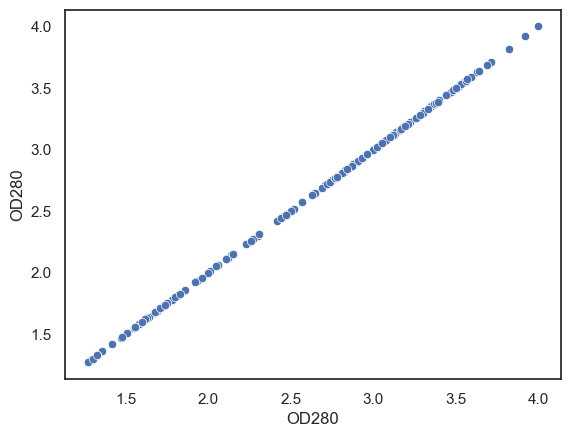

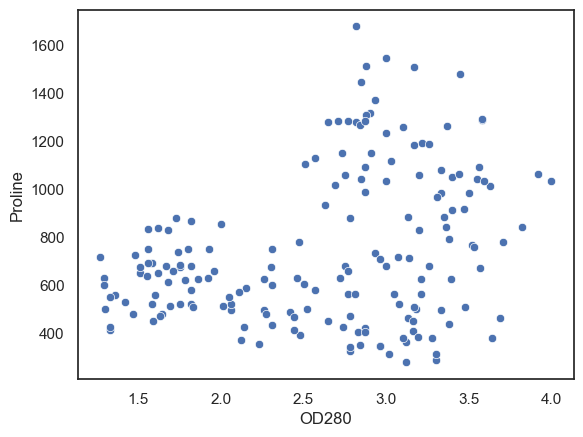

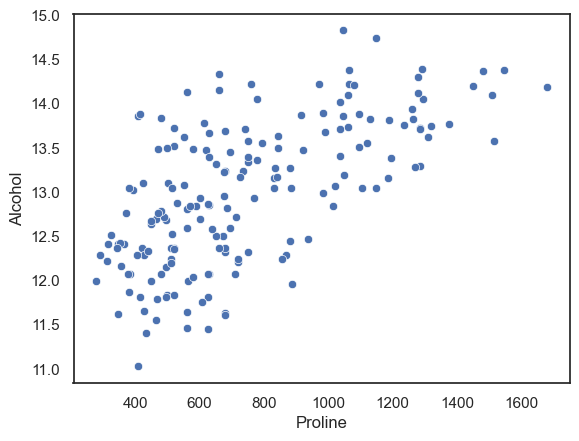

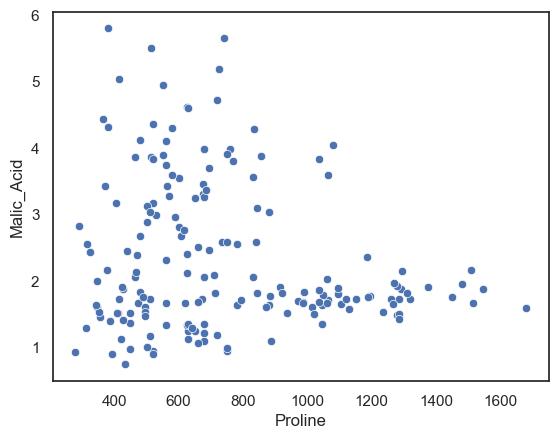

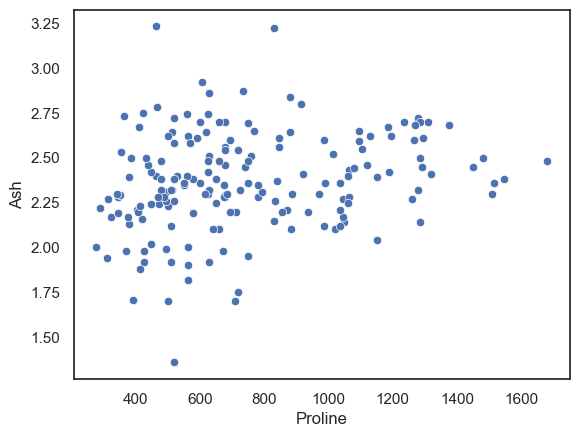

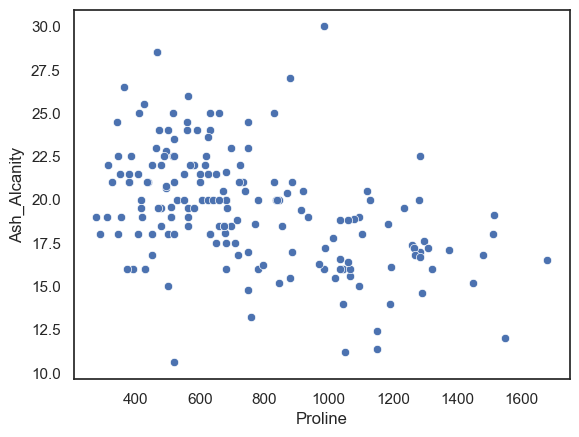

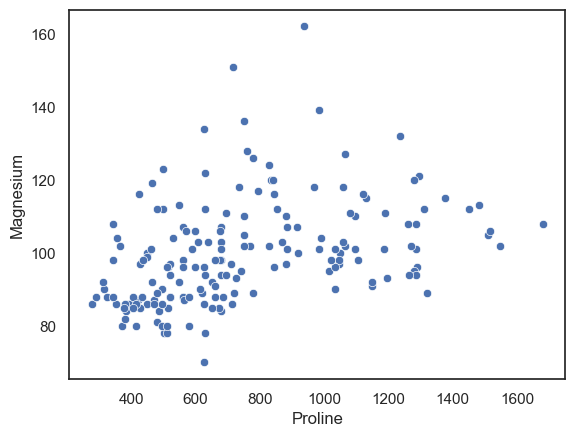

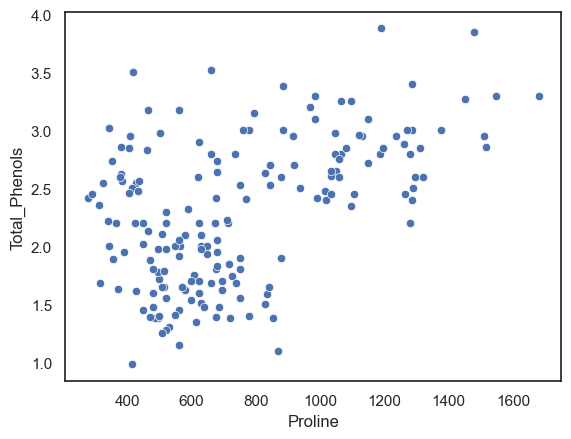

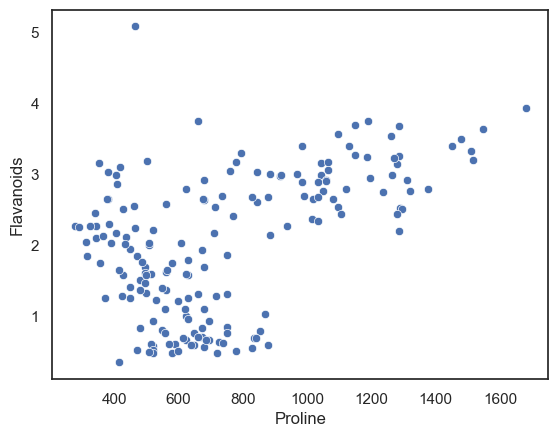

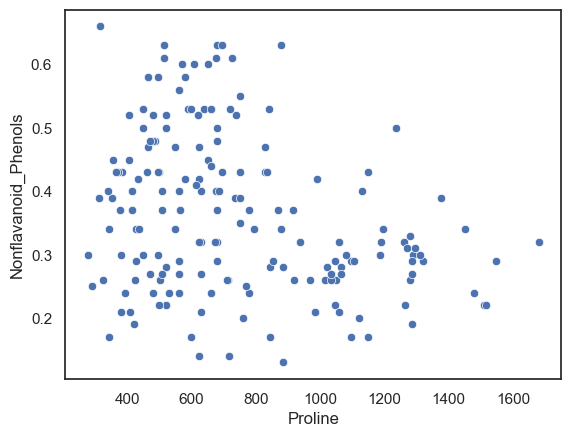

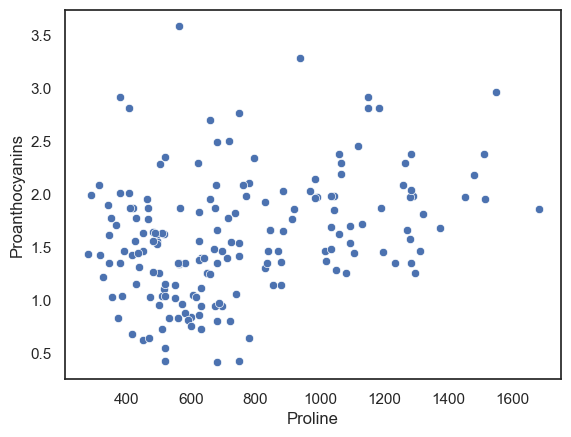

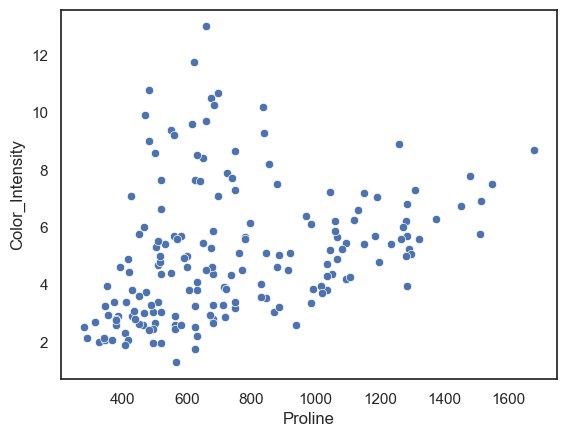

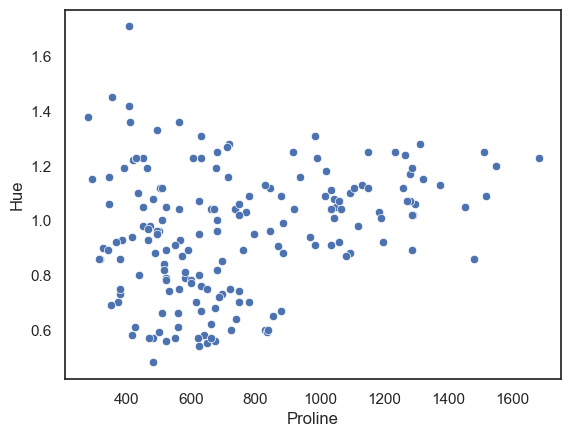

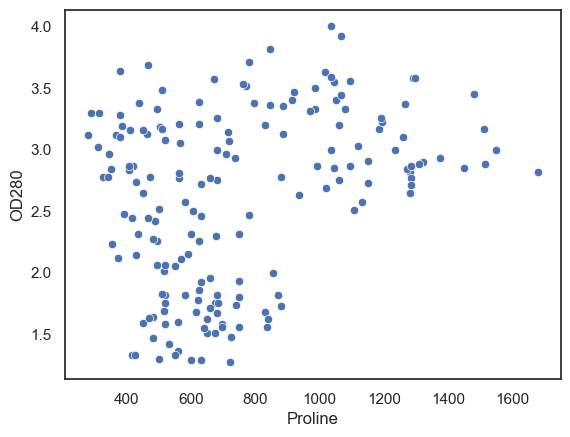

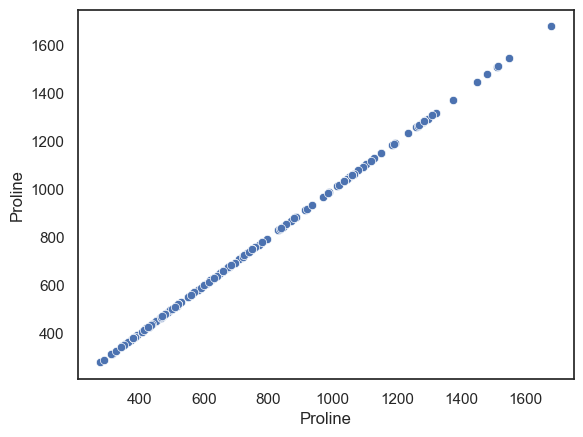

In [3]:
for i in df.columns:
    for j in df.columns:
        sns.scatterplot(x=df[i], y=df[j])
        plt.show()
        plt.close()

In [4]:
data = df[['OD280','Ash']]
data

,OD280,Ash
0,3.92,2.43
1,3.40,2.14
2,3.17,2.67
3,3.45,2.50
4,2.93,2.87
...,...,...
173,1.74,2.45
174,1.56,2.48
175,1.56,2.26
176,1.62,2.37


In [5]:
def evklid_di(X, Y):
    X, Y = np.array(X), np.array(Y)
    return sum((X - Y)**2)**(1/2)
evklid_di(np.array([2,2]), np.array([2,1]))

np.float64(1.0)

In [6]:
np.argmin(np.array([1,2,4,5,6,-2,3]))

np.int64(5)

In [7]:
np.array([0]) + np.array([1.3,2.2,3.2]) + np.array([1.3,2.2,3.2])
np.array([[[1,2,3], [2,3,4], [3,4,5]], [[1,2,3], [2,3,4], [3,4,5]]]).mean(axis=1)

array([[2., 3., 4.],
       [2., 3., 4.]])

In [8]:
np.sum([[1,2,3], [20,30,40], [3,4,5]], axis=1)/len([[1,2,3], [2,3,4], [3,4,5]])

array([ 2., 30.,  4.])

In [10]:
data_values = data.values


<Axes: >

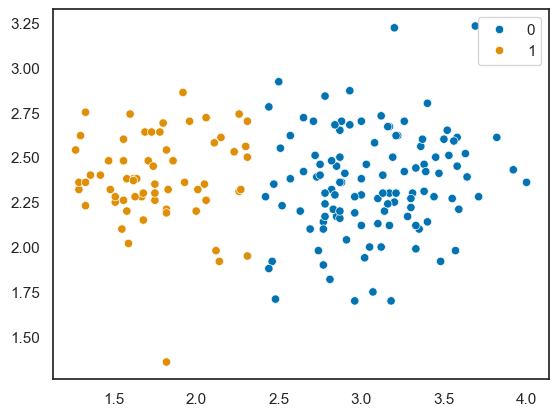

In [26]:
np.random.seed(14)

k, cluster_list, res = 2, [], []

data_values = data.values
k_start_random_new, k_start_random_old = data.sample(k).values, np.zeros((k, data_values.shape[1]))


while np.sum((k_start_random_new - k_start_random_old)**2) > 0.01:

    for point_data_i in range(len(data_values)):
        for point_cluster in k_start_random_new:
            cluster_list.append(evklid_di(data_values[point_data_i], point_cluster))
        res.append([*data_values[point_data_i],np.argmin(np.array(cluster_list))])

        cluster_list  = []

    k_start_random_old, k_start_random_new = k_start_random_new, np.array([(np.sum(k, axis=0)/len(k))[:2] for k in [[i for i in res if i[2]==j] for j in range(k)]])

sns.scatterplot(x=list(map(lambda x: x[0], res)), y=list(map(lambda x: x[1], res)), hue=list(map(lambda x: x[2], res)), palette="colorblind")



In [33]:
def k_means(
        data,
        k: str = 2,
        random_state: str = 14,
        learning_rate: str = 0.01
):
    def evklid_di(X, Y):
        X, Y = np.array(X), np.array(Y)
        return sum((X - Y)**2)**(1/2)

    np.random.seed(random_state)

    k, cluster_list, res = k, [], []

    data_values = data.values
    
    k_start_random_new, k_start_random_old = data.sample(k).values, np.zeros((k, data_values.shape[1]))
    

    while np.sum((k_start_random_new - k_start_random_old)**2) > learning_rate:

        for point_data_i in range(len(data_values)):
            for point_cluster in k_start_random_new:
                cluster_list.append(evklid_di(data_values[point_data_i], point_cluster))

            res.append([*data_values[point_data_i],np.argmin(np.array(cluster_list))])

            cluster_list  = []

        k_start_random_old, k_start_random_new = k_start_random_new, np.array([(np.sum(k, axis=0)/len(k))[:2] for k in [[i for i in res if i[2]==j] for j in range(k)]])

    sns.scatterplot(x=list(map(lambda x: x[0], res)), y=list(map(lambda x: x[1], res)), hue=list(map(lambda x: x[2], res)), palette="colorblind")



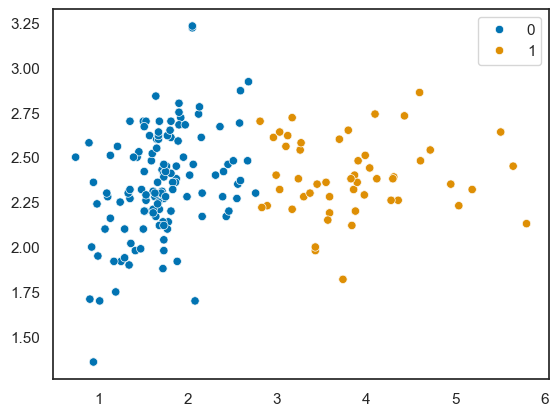

In [34]:
k_means(df[df.columns[1:3]])

In [35]:
data_values

array([[3.92, 2.43],
       [3.4 , 2.14],
       [3.17, 2.67],
       [3.45, 2.5 ],
       [2.93, 2.87],
       [2.85, 2.45],
       [3.58, 2.45],
       [3.58, 2.61],
       [2.85, 2.17],
       [3.55, 2.27],
       [3.17, 2.3 ],
       [2.82, 2.32],
       [2.9 , 2.41],
       [2.73, 2.39],
       [3.  , 2.38],
       [2.88, 2.7 ],
       [2.65, 2.72],
       [2.57, 2.62],
       [2.82, 2.48],
       [3.36, 2.56],
       [3.71, 2.28],
       [3.52, 2.65],
       [4.  , 2.36],
       [3.63, 2.52],
       [3.82, 2.61],
       [3.2 , 3.22],
       [3.22, 2.62],
       [2.77, 2.14],
       [3.4 , 2.8 ],
       [3.59, 2.21],
       [2.71, 2.7 ],
       [2.88, 2.36],
       [2.87, 2.36],
       [3.  , 2.7 ],
       [2.87, 2.65],
       [3.47, 2.41],
       [2.78, 2.84],
       [2.51, 2.55],
       [2.69, 2.1 ],
       [3.53, 2.51],
       [3.38, 2.31],
       [3.  , 2.12],
       [3.56, 2.59],
       [3.  , 2.29],
       [3.35, 2.1 ],
       [3.33, 2.44],
       [3.44, 2.28],
       [3.33,

In [46]:
def U_set(data, x, e: str = 0.6):
    return [_ for _ in data if evklid_di(x, _) < e]
U(data_values, [1,3])

[array([1.27, 2.54]), array([1.3 , 2.62]), array([1.33, 2.75])]

In [54]:
np.random.choice([10, 10, 11])

np.int64(11)

In [56]:
for _ in enumerate([[1,2], [3,4]]):
    print(_)

(0, [1, 2])
(1, [3, 4])


In [ ]:
U, m = enumerate(data_values), 3
mark = {}
A = [-1 for _ in range(len(data_values))]
a = 0
while len(U) != 0:
    x = np.random.choice(U)
    if len(U_set(x)) < m:
        mark[k] = 'шум'
    else:
        K = U_set(x)
        a += 1
        for x_ in [_[1] for _ in K]:
            if x_ in U or mark[x] == 'шум':
                if len(U_set(x_)) >= m:
                    mark[x_] = 'внутри'
                    K += U_set(x_)
                else:
                    mark[x_] = 'граница'
        for i in range(len(K)):



SyntaxError: incomplete input (1056070340.py, line 5)